### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import generate_covariance_matrix

from hebbian.utils import instantiate_samples_by_cov, rotation_matrix_nd


In [2]:
N = 16
m = 4
phi_deg = 75.0
n_samples = 10001
X_seed = 0
# get /sigma
# eigenvalues = np.array([2.0, 0.8])  # Your desired eigenvalues
eigenvalues = np.array([12.0, 5.0, 1.0, 0.1])
# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

R = rotation_matrix_nd(m, axis1=0, axis2=1, phi_rad=np.deg2rad(phi_deg))
Sigma_rot = R @ Sigma @ R.T

X_before = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)
X_after = instantiate_samples_by_cov(Sigma_rot, N, m, seed=X_seed, n_samples=n_samples)

# B. Generate Data (Rotate 45 degrees), if I want to purely rotate the data,
# but usually we want to simulate the data based on the rotated covariance matrix,
# so discard it:
# X_before, X_after = instantiate_rotated_data(N, m, Sigma, phi_rad=np.deg2rad(phi_deg), seed=X_seed, n_samples=n_samples)


# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [12.05206899  4.96324792  1.00753781  0.10095146]
Eigen values of X after: [12.05206899  4.96324792  1.00753781  0.10095146]
Variance explained by each PC of X before: [0.66498554 0.27385241 0.05559195 0.0055701 ]
Variance explained by each PC of X after: [0.66498554 0.27385241 0.05559195 0.0055701 ]


### Apply Leen's complete model to before and after drifted models

### Multiple runs

In [3]:
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online
### Two phase training and testing
def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True, alignment = "eigenvectors"):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, X=data_before, graph=True, alignment=alignment)
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")

        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, X=data_after, graph=True, alignment=alignment)

        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Leen's complete model

In [4]:
from hebbian.models import OneShotLeenCompletePCA, OneShotLeenFreislebenPCA, SangerNetwork, LeenCompletePCA, LeenCompletePCA_TD, OjaNetwork
# runs = 10
model_paras = dict(
    input_size=N, output_size=m,
    eta_w=5e-4,          # base
    eta_v=1e-3,          # ~4x eta_w
    C=3,
    # ema_alpha=0.05,
    symmetrize_V=True,
    seed=None,
    # noise_level=0.001,
    # settling_steps=10
)


_model_paras = dict(
    input_size=N, output_size=m,
    eta_w=1e-4,          # base
    eta_v=1e-3,          # ~4x eta_w
    C=1.0,
    # ema_alpha=0.05,
    symmetrize_V=True,
    seed=None,
    # noise_level=0.001,
    # # settling_steps=10
)



model_paras_after = dict(
    eta_w=5e-4,
    eta_v=5e-3,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

run  1
X_before
step    0 | order = [3 0 2 1] | best|corr|= [0.461 0.513 0.503 0.11 ]
step 1000 | order = [3 0 1 2] | best|corr|= [0.478 0.983 0.957 0.102]
step 2000 | order = [3 0 1 2] | best|corr|= [0.504 0.999 0.997 0.19 ]
step 3000 | order = [3 0 1 2] | best|corr|= [0.52  1.    0.997 0.288]
step 4000 | order = [3 0 1 2] | best|corr|= [0.532 0.996 0.999 0.389]
step 5000 | order = [3 0 1 2] | best|corr|= [0.544 0.995 1.    0.474]
step 6000 | order = [3 0 1 2] | best|corr|= [0.556 0.996 0.994 0.534]
step 7000 | order = [3 0 1 2] | best|corr|= [0.565 1.    1.    0.572]
step 8000 | order = [3 0 1 2] | best|corr|= [0.576 1.    0.999 0.61 ]
step 9000 | order = [3 0 1 2] | best|corr|= [0.581 1.    1.    0.633]
step 10000 | order = [3 0 1 2] | best|corr|= [0.577 0.992 1.    0.644]


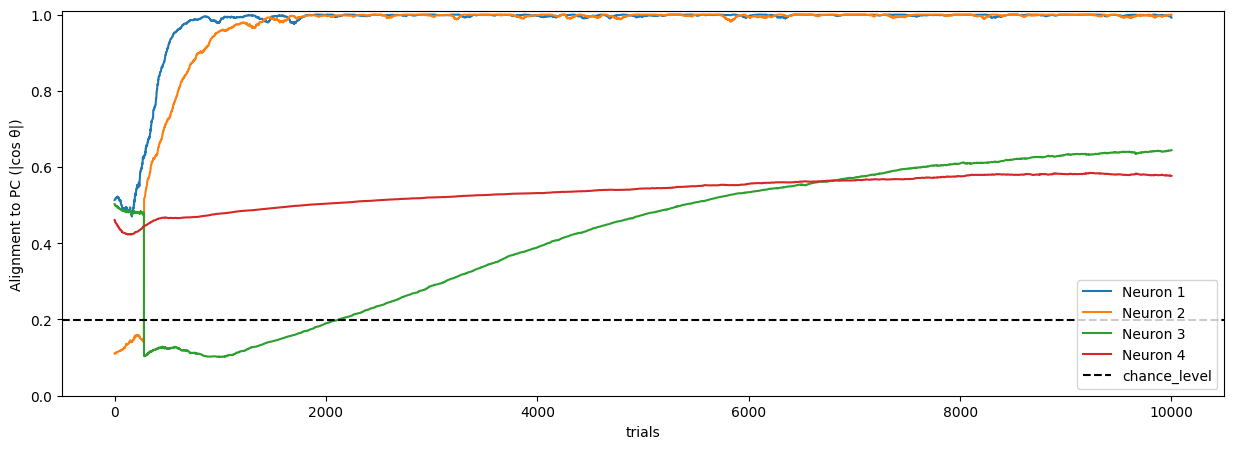

X_after
step    0 | order = [1 0 2 3] | best|corr|= [0.792 0.967 0.852 0.798]
step 1000 | order = [1 0 2 3] | best|corr|= [0.968 0.997 0.974 0.829]
step 2000 | order = [1 0 2 3] | best|corr|= [0.997 1.    0.989 0.847]
step 3000 | order = [1 0 2 3] | best|corr|= [0.996 1.    0.995 0.856]
step 4000 | order = [1 0 2 3] | best|corr|= [0.998 0.997 0.996 0.866]
step 5000 | order = [1 0 2 3] | best|corr|= [1.    0.995 0.998 0.876]
step 6000 | order = [1 0 2 3] | best|corr|= [0.994 0.996 0.999 0.884]
step 7000 | order = [1 0 2 3] | best|corr|= [1.    1.    0.999 0.893]
step 8000 | order = [1 0 2 3] | best|corr|= [0.999 1.    0.999 0.902]
step 9000 | order = [1 0 2 3] | best|corr|= [1.    1.    0.997 0.91 ]
step 10000 | order = [1 0 2 3] | best|corr|= [1.    0.992 0.999 0.918]


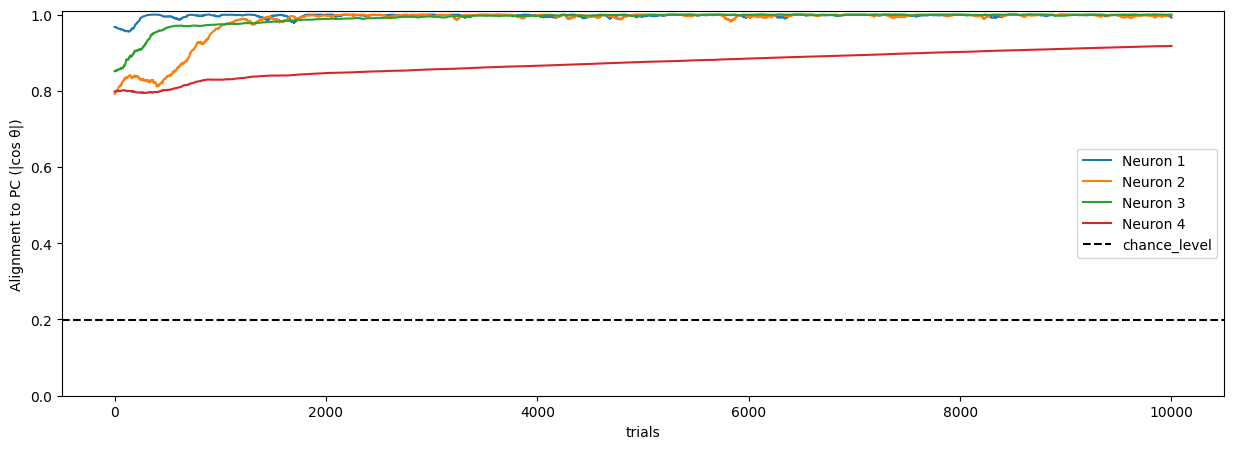

run  2
X_before
step    0 | order = [3 0 2 1] | best|corr|= [0.458 0.316 0.222 0.317]
step 1000 | order = [2 1 0 3] | best|corr|= [0.58  0.838 0.993 0.169]
step 2000 | order = [2 1 0 3] | best|corr|= [0.743 0.996 0.999 0.249]
step 3000 | order = [2 1 0 3] | best|corr|= [0.849 0.997 1.    0.286]
step 4000 | order = [2 1 0 3] | best|corr|= [0.92  0.998 0.997 0.3  ]
step 5000 | order = [2 1 0 3] | best|corr|= [0.962 1.    0.995 0.308]
step 6000 | order = [2 1 0 3] | best|corr|= [0.986 0.994 0.996 0.316]
step 7000 | order = [2 1 0 3] | best|corr|= [0.994 1.    1.    0.327]
step 8000 | order = [2 1 0 3] | best|corr|= [0.996 0.999 1.    0.34 ]
step 9000 | order = [2 1 0 3] | best|corr|= [0.997 1.    1.    0.356]
step 10000 | order = [2 1 0 3] | best|corr|= [0.999 1.    0.992 0.372]


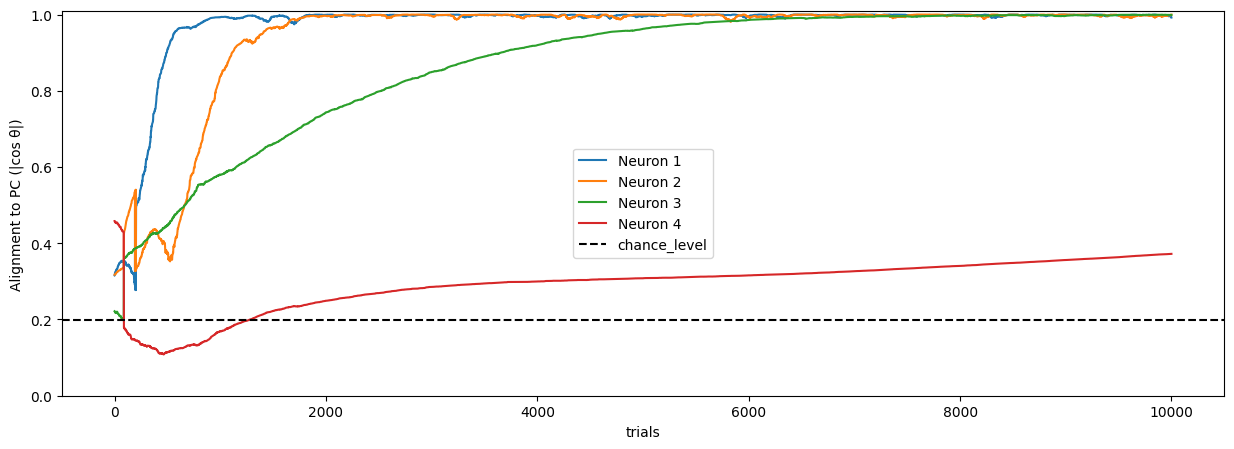

X_after
step    0 | order = [3 2 0 1] | best|corr|= [0.687 0.847 0.968 0.252]
step 1000 | order = [1 2 0 3] | best|corr|= [0.858 0.994 0.996 0.279]
step 2000 | order = [1 2 0 3] | best|corr|= [0.992 0.997 1.    0.301]
step 3000 | order = [1 2 0 3] | best|corr|= [0.996 0.998 1.    0.314]
step 4000 | order = [1 2 0 3] | best|corr|= [0.998 0.997 0.997 0.328]
step 5000 | order = [1 2 0 3] | best|corr|= [1.    0.998 0.995 0.342]
step 6000 | order = [1 2 0 3] | best|corr|= [0.994 1.    0.996 0.356]
step 7000 | order = [1 2 0 3] | best|corr|= [1.    0.999 1.    0.371]
step 8000 | order = [1 2 0 3] | best|corr|= [0.999 0.999 1.    0.387]
step 9000 | order = [1 2 0 3] | best|corr|= [1.    0.997 1.    0.404]
step 10000 | order = [1 2 0 3] | best|corr|= [1.    0.999 0.992 0.421]


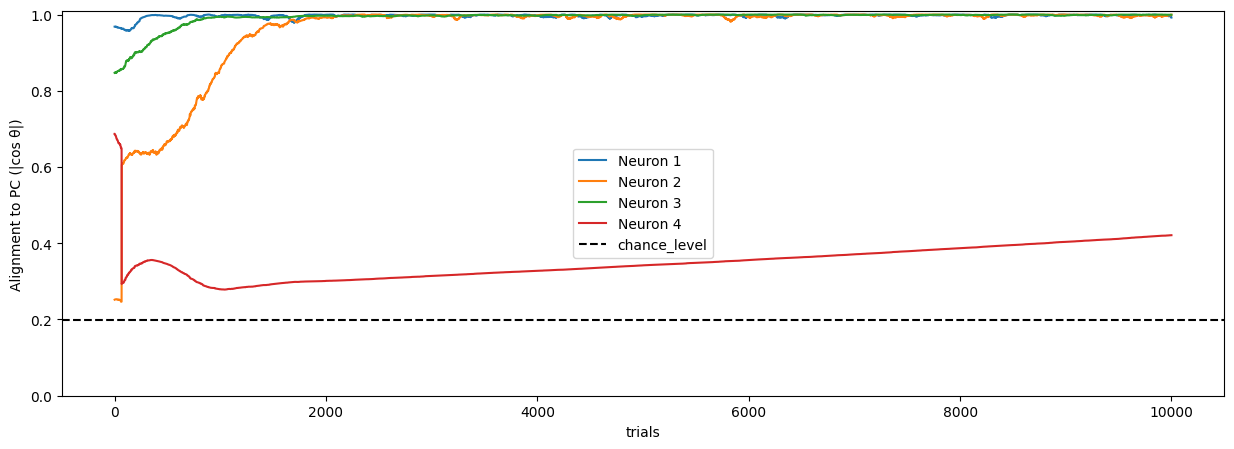

run  3
X_before
step    0 | order = [3 0 1 2] | best|corr|= [0.087 0.251 0.361 0.427]
step 1000 | order = [3 0 1 2] | best|corr|= [0.087 0.998 0.957 0.616]
step 2000 | order = [3 0 1 2] | best|corr|= [0.072 1.    0.998 0.756]
step 3000 | order = [3 0 1 2] | best|corr|= [0.072 1.    0.997 0.865]
step 4000 | order = [3 0 1 2] | best|corr|= [0.081 0.997 0.998 0.933]
step 5000 | order = [3 0 1 2] | best|corr|= [0.092 0.995 1.    0.971]
step 6000 | order = [3 0 1 2] | best|corr|= [0.101 0.996 0.994 0.989]
step 7000 | order = [3 0 1 2] | best|corr|= [0.107 1.    1.    0.995]
step 8000 | order = [3 0 1 2] | best|corr|= [0.112 1.    0.999 0.997]
step 9000 | order = [3 0 1 2] | best|corr|= [0.118 1.    1.    0.997]
step 10000 | order = [3 0 1 2] | best|corr|= [0.124 0.992 1.    0.999]


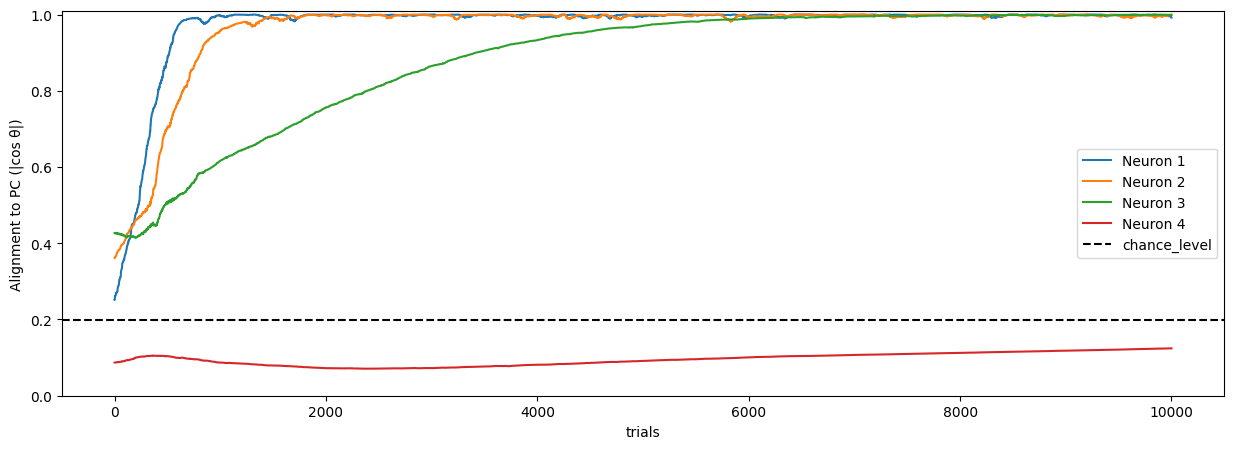

X_after
step    0 | order = [1 0 2 3] | best|corr|= [0.085 0.968 0.847 0.681]
step 1000 | order = [3 0 2 1] | best|corr|= [0.089 0.996 0.994 0.877]
step 2000 | order = [3 0 2 1] | best|corr|= [0.096 1.    0.997 0.993]
step 3000 | order = [3 0 2 1] | best|corr|= [0.1   1.    0.998 0.996]
step 4000 | order = [3 0 2 1] | best|corr|= [0.105 0.997 0.997 0.998]
step 5000 | order = [3 0 2 1] | best|corr|= [0.11  0.995 0.998 1.   ]
step 6000 | order = [3 0 2 1] | best|corr|= [0.115 0.996 1.    0.994]
step 7000 | order = [3 0 2 1] | best|corr|= [0.121 1.    0.999 1.   ]
step 8000 | order = [3 0 2 1] | best|corr|= [0.127 1.    0.999 0.999]
step 9000 | order = [3 0 2 1] | best|corr|= [0.133 1.    0.997 1.   ]
step 10000 | order = [3 0 2 1] | best|corr|= [0.14  0.992 0.999 1.   ]


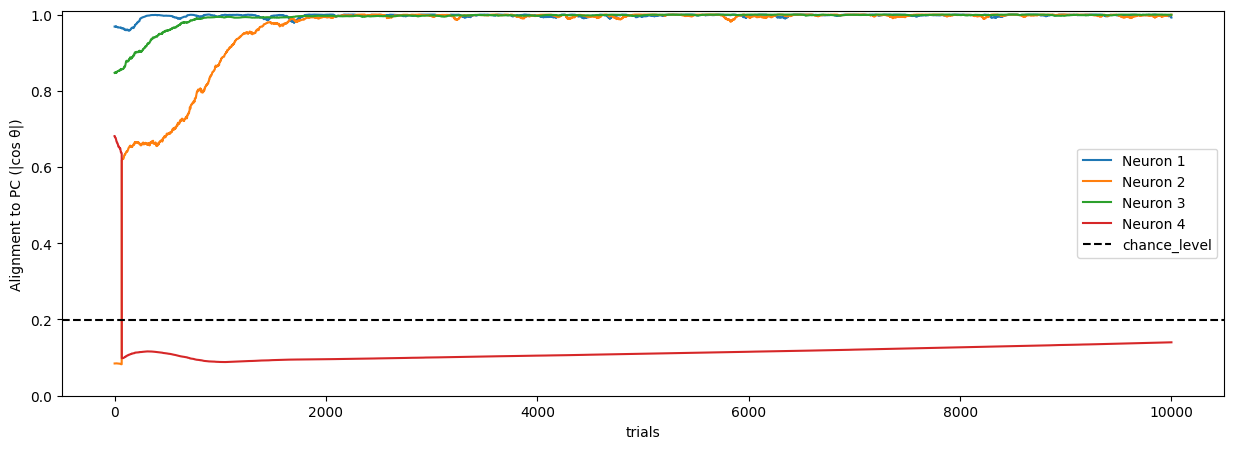

run  4
X_before
step    0 | order = [3 0 1 2] | best|corr|= [0.23  0.515 0.235 0.538]
step 1000 | order = [1 0 3 2] | best|corr|= [0.943 0.998 0.004 0.718]
step 2000 | order = [1 0 3 2] | best|corr|= [0.998 1.    0.    0.862]
step 3000 | order = [1 0 3 2] | best|corr|= [0.997 1.    0.001 0.941]
step 4000 | order = [1 0 3 2] | best|corr|= [0.998 0.997 0.001 0.973]
step 5000 | order = [1 0 3 2] | best|corr|= [1.    0.995 0.001 0.988]
step 6000 | order = [1 0 3 2] | best|corr|= [0.994 0.996 0.001 0.996]
step 7000 | order = [1 0 3 2] | best|corr|= [1.    1.    0.001 0.998]
step 8000 | order = [1 0 3 2] | best|corr|= [0.999 1.    0.001 0.998]
step 9000 | order = [1 0 3 2] | best|corr|= [1.    1.    0.001 0.997]
step 10000 | order = [1 0 3 2] | best|corr|= [1.    0.992 0.001 0.999]


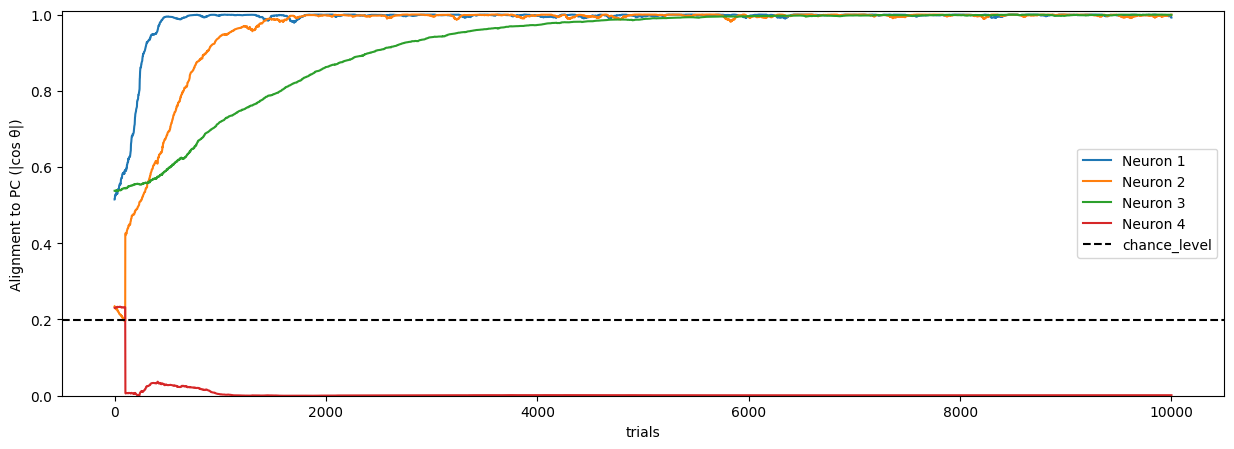

X_after
step    0 | order = [2 0 1 3] | best|corr|= [0.847 0.968 0.001 0.675]
step 1000 | order = [2 0 3 1] | best|corr|= [0.994 0.996 0.001 0.885]
step 2000 | order = [2 0 3 1] | best|corr|= [0.996 1.    0.001 0.993]
step 3000 | order = [2 0 3 1] | best|corr|= [0.998 1.    0.001 0.996]
step 4000 | order = [2 0 3 1] | best|corr|= [0.997 0.997 0.001 0.998]
step 5000 | order = [2 0 3 1] | best|corr|= [0.998 0.995 0.002 1.   ]
step 6000 | order = [2 0 3 1] | best|corr|= [1.    0.996 0.002 0.994]
step 7000 | order = [2 0 3 1] | best|corr|= [0.999 1.    0.002 1.   ]
step 8000 | order = [2 0 3 1] | best|corr|= [0.999 1.    0.002 0.999]
step 9000 | order = [2 0 3 1] | best|corr|= [0.997 1.    0.002 1.   ]
step 10000 | order = [2 0 3 1] | best|corr|= [0.999 0.992 0.002 1.   ]


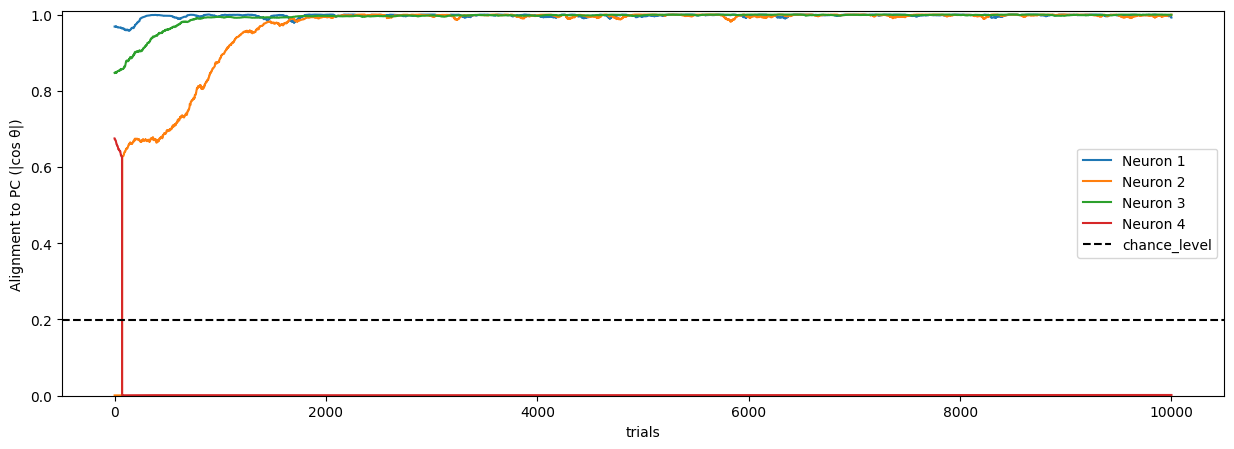

run  5
X_before
step    0 | order = [2 3 1 0] | best|corr|= [0.533 0.287 0.264 0.2  ]
step 1000 | order = [2 0 1 3] | best|corr|= [0.769 0.995 0.811 0.054]
step 2000 | order = [2 0 1 3] | best|corr|= [0.863 1.    0.994 0.053]
step 3000 | order = [2 0 1 3] | best|corr|= [0.936 1.    0.996 0.059]
step 4000 | order = [2 0 1 3] | best|corr|= [0.972 0.997 0.998 0.065]
step 5000 | order = [2 0 1 3] | best|corr|= [0.988 0.995 1.    0.069]
step 6000 | order = [2 0 1 3] | best|corr|= [0.996 0.996 0.994 0.072]
step 7000 | order = [2 0 1 3] | best|corr|= [0.998 1.    1.    0.076]
step 8000 | order = [2 0 1 3] | best|corr|= [0.998 1.    0.999 0.08 ]
step 9000 | order = [2 0 1 3] | best|corr|= [0.997 1.    1.    0.084]
step 10000 | order = [2 0 1 3] | best|corr|= [0.999 0.992 1.    0.088]


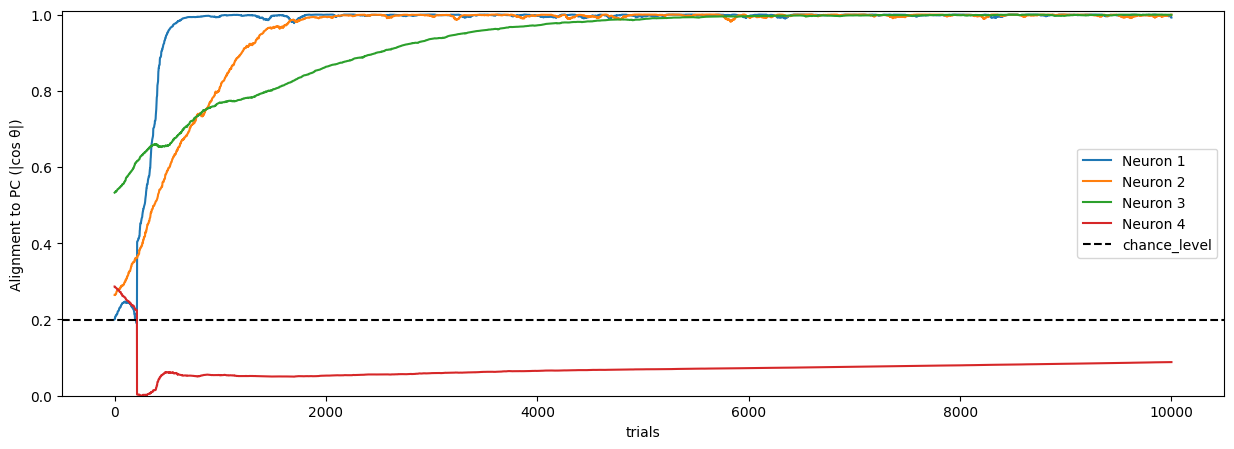

X_after
step    0 | order = [3 0 2 1] | best|corr|= [0.674 0.968 0.847 0.06 ]
step 1000 | order = [1 0 2 3] | best|corr|= [0.886 0.996 0.994 0.065]
step 2000 | order = [1 0 2 3] | best|corr|= [0.993 1.    0.996 0.07 ]
step 3000 | order = [1 0 2 3] | best|corr|= [0.996 1.    0.998 0.073]
step 4000 | order = [1 0 2 3] | best|corr|= [0.998 0.997 0.997 0.077]
step 5000 | order = [1 0 2 3] | best|corr|= [1.    0.995 0.998 0.08 ]
step 6000 | order = [1 0 2 3] | best|corr|= [0.994 0.996 1.    0.084]
step 7000 | order = [1 0 2 3] | best|corr|= [1.    1.    0.999 0.088]
step 8000 | order = [1 0 2 3] | best|corr|= [0.999 1.    0.999 0.092]
step 9000 | order = [1 0 2 3] | best|corr|= [1.    1.    0.997 0.097]
step 10000 | order = [1 0 2 3] | best|corr|= [1.    0.992 0.999 0.102]


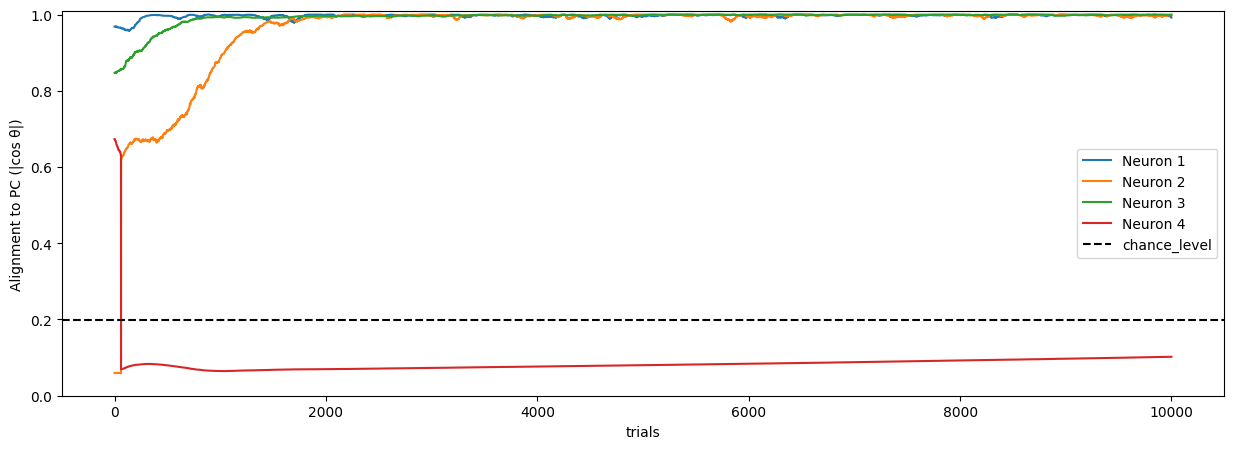

run  6
X_before
step    0 | order = [3 1 2 0] | best|corr|= [0.406 0.091 0.179 0.377]
step 1000 | order = [3 1 2 0] | best|corr|= [0.326 0.471 0.426 0.996]
step 2000 | order = [3 1 2 0] | best|corr|= [0.368 0.924 0.573 1.   ]
step 3000 | order = [3 1 2 0] | best|corr|= [0.399 0.996 0.691 1.   ]
step 4000 | order = [3 1 2 0] | best|corr|= [0.441 0.999 0.795 0.996]
step 5000 | order = [3 1 2 0] | best|corr|= [0.493 1.    0.884 0.995]
step 6000 | order = [3 1 2 0] | best|corr|= [0.538 0.994 0.947 0.996]
step 7000 | order = [3 1 2 0] | best|corr|= [0.567 1.    0.979 1.   ]
step 8000 | order = [3 1 2 0] | best|corr|= [0.589 0.999 0.991 1.   ]
step 9000 | order = [3 1 2 0] | best|corr|= [0.609 1.    0.995 1.   ]
step 10000 | order = [3 1 2 0] | best|corr|= [0.628 1.    0.998 0.992]


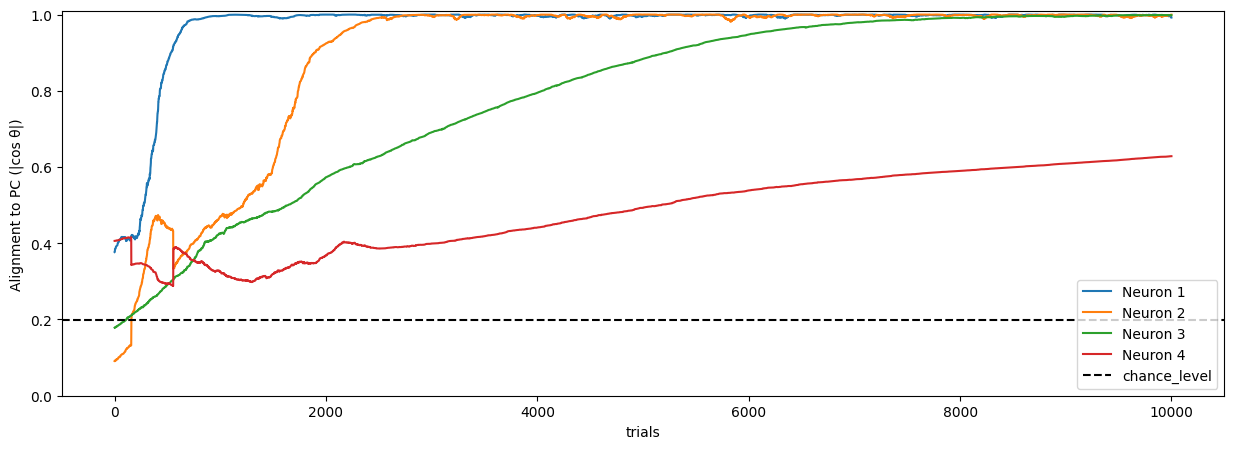

X_after
step    0 | order = [1 2 3 0] | best|corr|= [0.42  0.847 0.683 0.968]
step 1000 | order = [3 2 1 0] | best|corr|= [0.506 0.994 0.86  0.996]
step 2000 | order = [3 2 1 0] | best|corr|= [0.542 0.997 0.992 1.   ]
step 3000 | order = [3 2 1 0] | best|corr|= [0.561 0.998 0.996 1.   ]
step 4000 | order = [3 2 1 0] | best|corr|= [0.579 0.997 0.998 0.997]
step 5000 | order = [3 2 1 0] | best|corr|= [0.598 0.998 1.    0.995]
step 6000 | order = [3 2 1 0] | best|corr|= [0.615 1.    0.994 0.996]
step 7000 | order = [3 2 1 0] | best|corr|= [0.633 0.999 1.    1.   ]
step 8000 | order = [3 2 1 0] | best|corr|= [0.651 0.999 0.999 1.   ]
step 9000 | order = [3 2 1 0] | best|corr|= [0.67  0.997 1.    1.   ]
step 10000 | order = [3 2 1 0] | best|corr|= [0.689 0.999 1.    0.992]


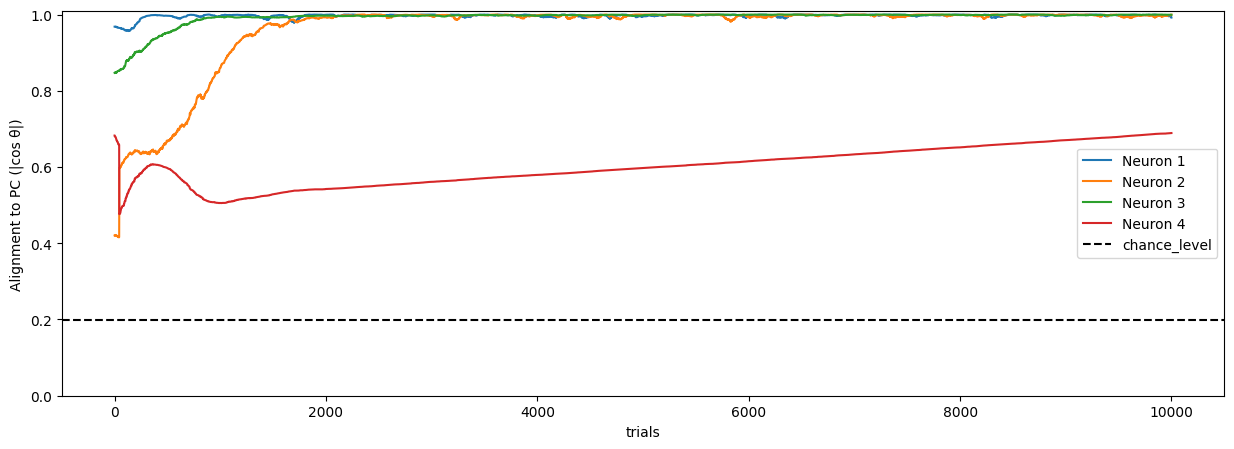

run  7
X_before
step    0 | order = [2 1 3 0] | best|corr|= [0.315 0.313 0.496 0.446]
step 1000 | order = [2 1 3 0] | best|corr|= [0.412 0.915 0.488 0.997]
step 2000 | order = [2 1 3 0] | best|corr|= [0.453 0.997 0.461 1.   ]
step 3000 | order = [2 1 3 0] | best|corr|= [0.444 0.997 0.442 1.   ]
step 4000 | order = [3 1 2 0] | best|corr|= [0.235 0.999 0.751 0.996]
step 5000 | order = [3 1 2 0] | best|corr|= [0.254 1.    0.84  0.996]
step 6000 | order = [3 1 2 0] | best|corr|= [0.263 0.994 0.917 0.996]
step 7000 | order = [3 1 2 0] | best|corr|= [0.263 1.    0.964 1.   ]
step 8000 | order = [3 1 2 0] | best|corr|= [0.268 0.999 0.984 1.   ]
step 9000 | order = [3 1 2 0] | best|corr|= [0.276 1.    0.992 1.   ]
step 10000 | order = [3 1 2 0] | best|corr|= [0.288 1.    0.997 0.992]


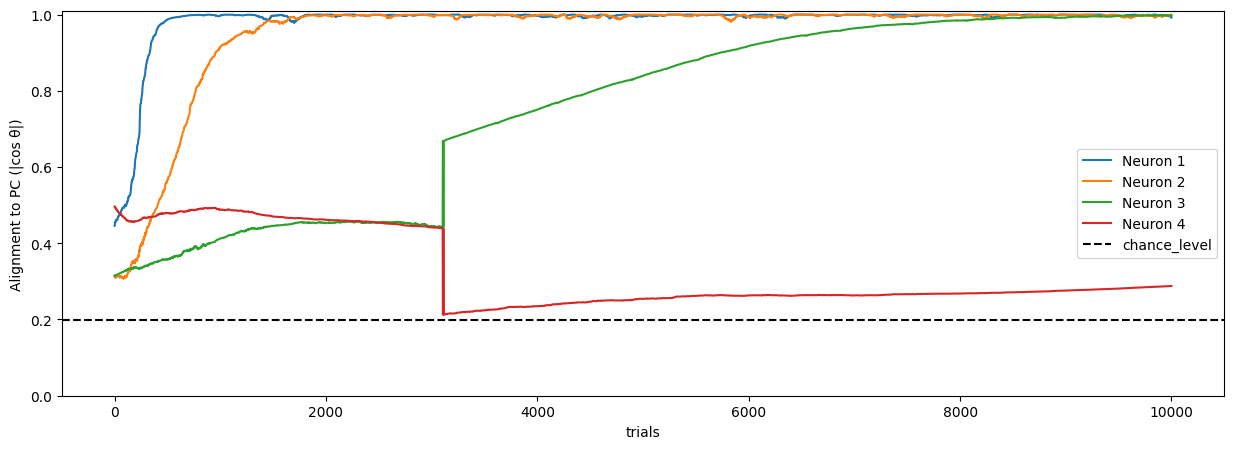

X_after
step    0 | order = [1 2 3 0] | best|corr|= [0.19  0.847 0.706 0.968]
step 1000 | order = [3 2 1 0] | best|corr|= [0.219 0.994 0.844 0.996]
step 2000 | order = [3 2 1 0] | best|corr|= [0.236 0.997 0.992 1.   ]
step 3000 | order = [3 2 1 0] | best|corr|= [0.246 0.998 0.996 1.   ]
step 4000 | order = [3 2 1 0] | best|corr|= [0.257 0.997 0.998 0.997]
step 5000 | order = [3 2 1 0] | best|corr|= [0.269 0.998 1.    0.995]
step 6000 | order = [3 2 1 0] | best|corr|= [0.28  1.    0.994 0.996]
step 7000 | order = [3 2 1 0] | best|corr|= [0.293 0.999 1.    1.   ]
step 8000 | order = [3 2 1 0] | best|corr|= [0.306 0.999 0.999 1.   ]
step 9000 | order = [3 2 1 0] | best|corr|= [0.321 0.997 1.    1.   ]
step 10000 | order = [3 2 1 0] | best|corr|= [0.335 0.999 1.    0.992]


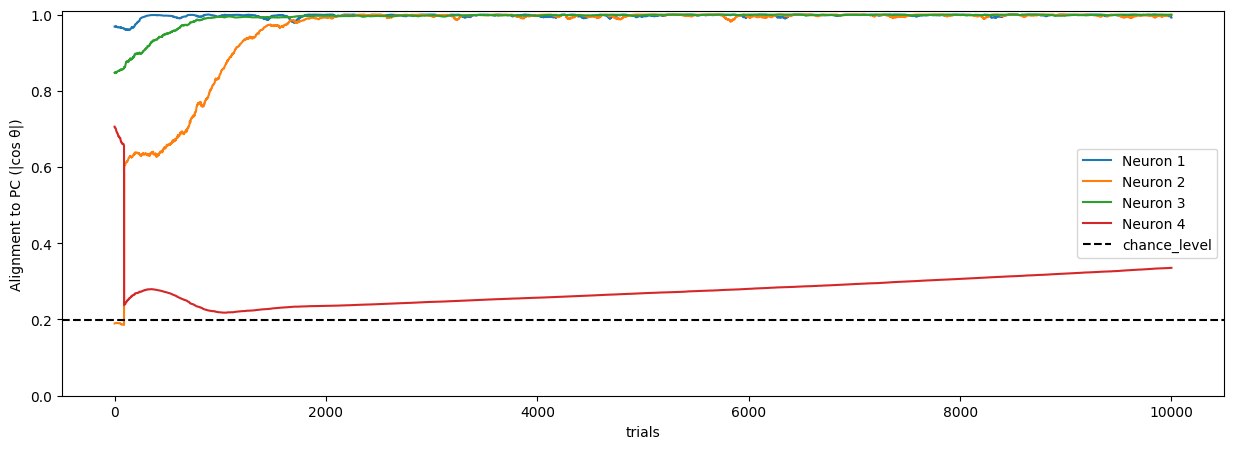

run  8
X_before
step    0 | order = [0 3 2 1] | best|corr|= [0.622 0.108 0.482 0.416]
step 1000 | order = [0 3 2 1] | best|corr|= [0.998 0.119 0.654 0.942]
step 2000 | order = [0 3 2 1] | best|corr|= [1.    0.124 0.812 0.997]
step 3000 | order = [0 3 2 1] | best|corr|= [1.    0.131 0.913 0.996]
step 4000 | order = [0 3 2 1] | best|corr|= [0.997 0.137 0.96  0.998]
step 5000 | order = [0 3 2 1] | best|corr|= [0.995 0.143 0.983 1.   ]
step 6000 | order = [0 3 2 1] | best|corr|= [0.996 0.15  0.993 0.994]
step 7000 | order = [0 3 2 1] | best|corr|= [1.    0.157 0.997 1.   ]
step 8000 | order = [0 3 2 1] | best|corr|= [1.    0.165 0.998 0.999]
step 9000 | order = [0 3 2 1] | best|corr|= [1.    0.173 0.997 1.   ]
step 10000 | order = [0 3 2 1] | best|corr|= [0.992 0.182 0.999 1.   ]


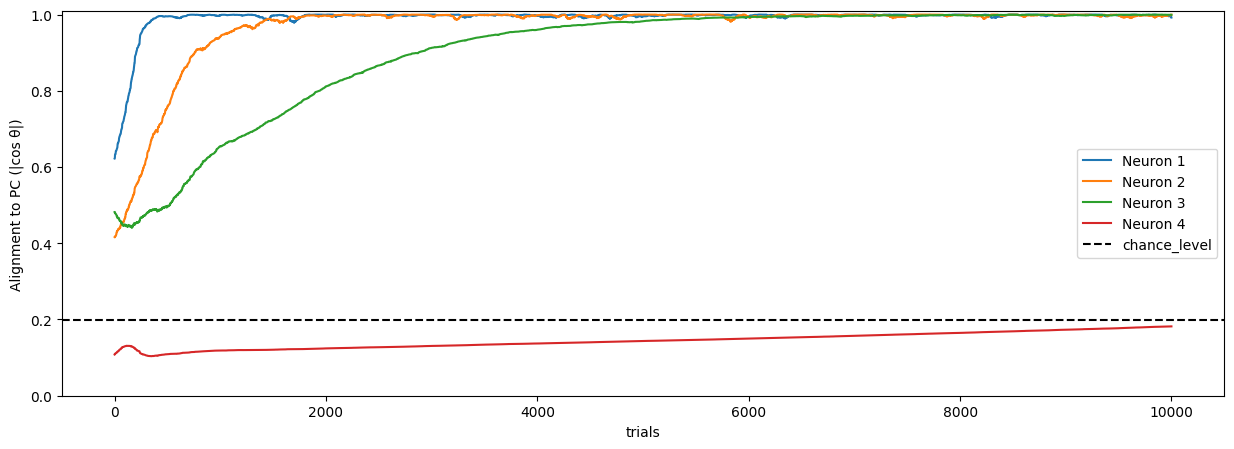

X_after
step    0 | order = [0 1 3 2] | best|corr|= [0.968 0.123 0.673 0.847]
step 1000 | order = [0 3 1 2] | best|corr|= [0.996 0.134 0.882 0.994]
step 2000 | order = [0 3 1 2] | best|corr|= [1.    0.144 0.993 0.997]
step 3000 | order = [0 3 1 2] | best|corr|= [1.    0.151 0.996 0.998]
step 4000 | order = [0 3 1 2] | best|corr|= [0.997 0.158 0.998 0.997]
step 5000 | order = [0 3 1 2] | best|corr|= [0.995 0.165 1.    0.998]
step 6000 | order = [0 3 1 2] | best|corr|= [0.996 0.173 0.994 1.   ]
step 7000 | order = [0 3 1 2] | best|corr|= [1.    0.181 1.    0.999]
step 8000 | order = [0 3 1 2] | best|corr|= [1.    0.19  0.999 0.999]
step 9000 | order = [0 3 1 2] | best|corr|= [1.    0.199 1.    0.997]
step 10000 | order = [0 3 1 2] | best|corr|= [0.992 0.209 1.    0.999]


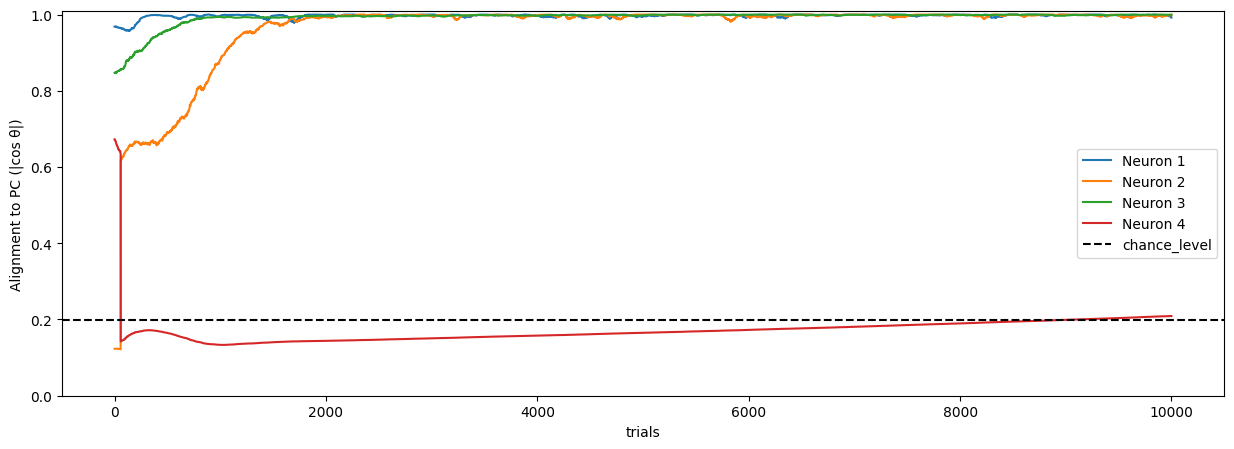

run  9
X_before
step    0 | order = [0 3 2 1] | best|corr|= [0.087 0.338 0.497 0.201]
step 1000 | order = [2 3 0 1] | best|corr|= [0.688 0.324 0.974 0.713]
step 2000 | order = [2 3 0 1] | best|corr|= [0.808 0.361 0.999 0.994]
step 3000 | order = [2 3 0 1] | best|corr|= [0.88  0.391 1.    0.997]
step 4000 | order = [2 3 0 1] | best|corr|= [0.933 0.416 0.996 0.998]
step 5000 | order = [2 3 0 1] | best|corr|= [0.968 0.436 0.995 1.   ]
step 6000 | order = [2 3 0 1] | best|corr|= [0.988 0.45  0.996 0.994]
step 7000 | order = [2 3 0 1] | best|corr|= [0.995 0.466 1.    1.   ]
step 8000 | order = [2 3 0 1] | best|corr|= [0.997 0.483 1.    0.999]
step 9000 | order = [2 3 0 1] | best|corr|= [0.997 0.502 1.    1.   ]
step 10000 | order = [2 3 0 1] | best|corr|= [0.999 0.521 0.992 1.   ]


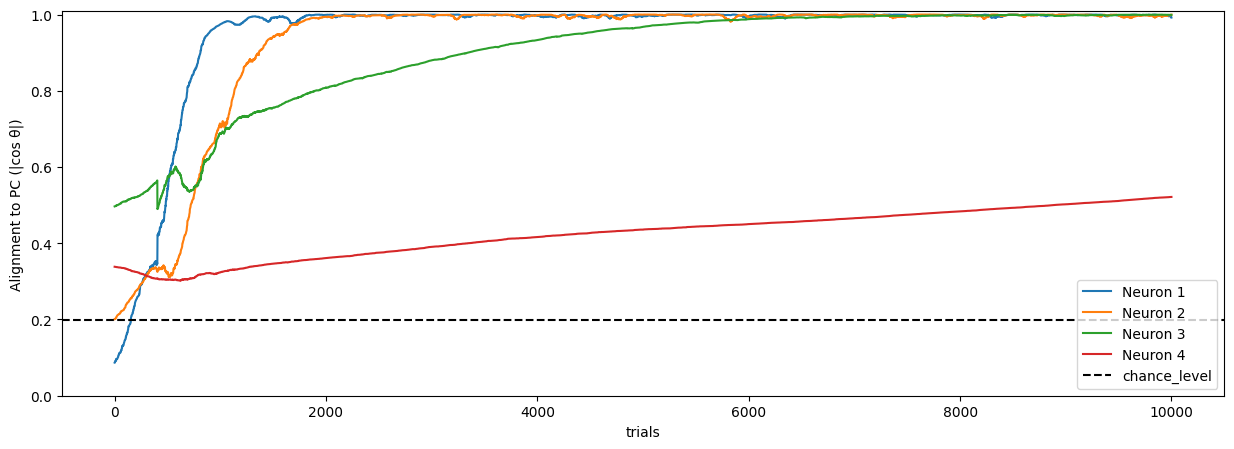

X_after
step    0 | order = [3 1 0 2] | best|corr|= [0.683 0.353 0.968 0.847]
step 1000 | order = [1 3 0 2] | best|corr|= [0.839 0.405 0.996 0.994]
step 2000 | order = [1 3 0 2] | best|corr|= [0.991 0.436 1.    0.997]
step 3000 | order = [1 3 0 2] | best|corr|= [0.996 0.452 1.    0.998]
step 4000 | order = [1 3 0 2] | best|corr|= [0.998 0.47  0.997 0.997]
step 5000 | order = [1 3 0 2] | best|corr|= [1.    0.487 0.995 0.998]
step 6000 | order = [1 3 0 2] | best|corr|= [0.994 0.504 0.996 1.   ]
step 7000 | order = [1 3 0 2] | best|corr|= [1.    0.522 1.    0.999]
step 8000 | order = [1 3 0 2] | best|corr|= [0.999 0.541 1.    0.999]
step 9000 | order = [1 3 0 2] | best|corr|= [1.    0.56  1.    0.997]
step 10000 | order = [1 3 0 2] | best|corr|= [1.    0.58  0.992 0.999]


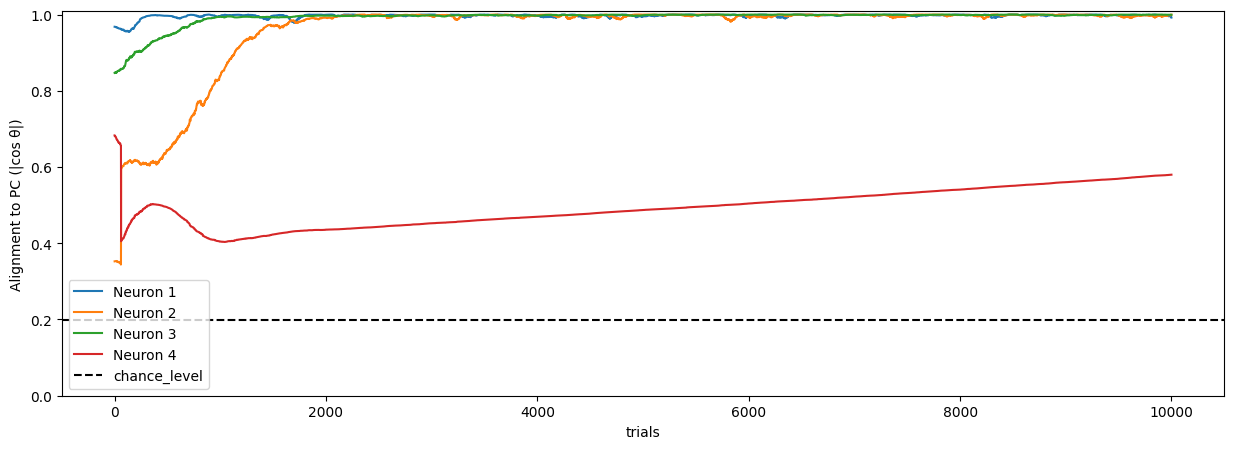

run 10
X_before
step    0 | order = [2 3 1 0] | best|corr|= [0.431 0.229 0.308 0.393]
step 1000 | order = [0 2 1 3] | best|corr|= [0.996 0.282 0.947 0.239]
step 2000 | order = [0 2 1 3] | best|corr|= [1.    0.406 0.998 0.274]
step 3000 | order = [0 2 1 3] | best|corr|= [1.    0.549 0.997 0.297]
step 4000 | order = [0 2 1 3] | best|corr|= [0.996 0.681 0.999 0.324]
step 5000 | order = [0 2 1 3] | best|corr|= [0.995 0.8   1.    0.356]
step 6000 | order = [0 2 1 3] | best|corr|= [0.996 0.898 0.994 0.383]
step 7000 | order = [0 2 1 3] | best|corr|= [1.    0.955 1.    0.393]
step 8000 | order = [0 2 1 3] | best|corr|= [1.    0.98  0.999 0.4  ]
step 9000 | order = [0 2 1 3] | best|corr|= [1.   0.99 1.   0.41]
step 10000 | order = [0 2 1 3] | best|corr|= [0.992 0.997 1.    0.425]


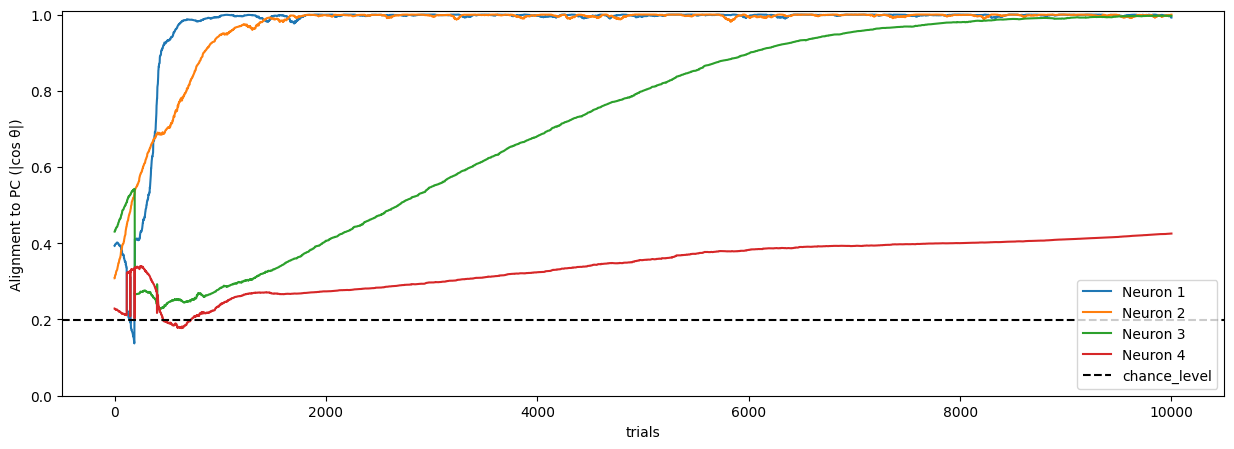

X_after
step    0 | order = [0 3 2 1] | best|corr|= [0.968 0.696 0.847 0.281]
step 1000 | order = [0 1 2 3] | best|corr|= [0.996 0.85  0.994 0.325]
step 2000 | order = [0 1 2 3] | best|corr|= [1.    0.992 0.997 0.351]
step 3000 | order = [0 1 2 3] | best|corr|= [1.    0.996 0.998 0.365]
step 4000 | order = [0 1 2 3] | best|corr|= [0.997 0.998 0.997 0.381]
step 5000 | order = [0 1 2 3] | best|corr|= [0.995 1.    0.998 0.396]
step 6000 | order = [0 1 2 3] | best|corr|= [0.996 0.994 1.    0.412]
step 7000 | order = [0 1 2 3] | best|corr|= [1.    1.    0.999 0.428]
step 8000 | order = [0 1 2 3] | best|corr|= [1.    0.999 0.999 0.445]
step 9000 | order = [0 1 2 3] | best|corr|= [1.    1.    0.997 0.464]
step 10000 | order = [0 1 2 3] | best|corr|= [0.992 1.    0.999 0.482]


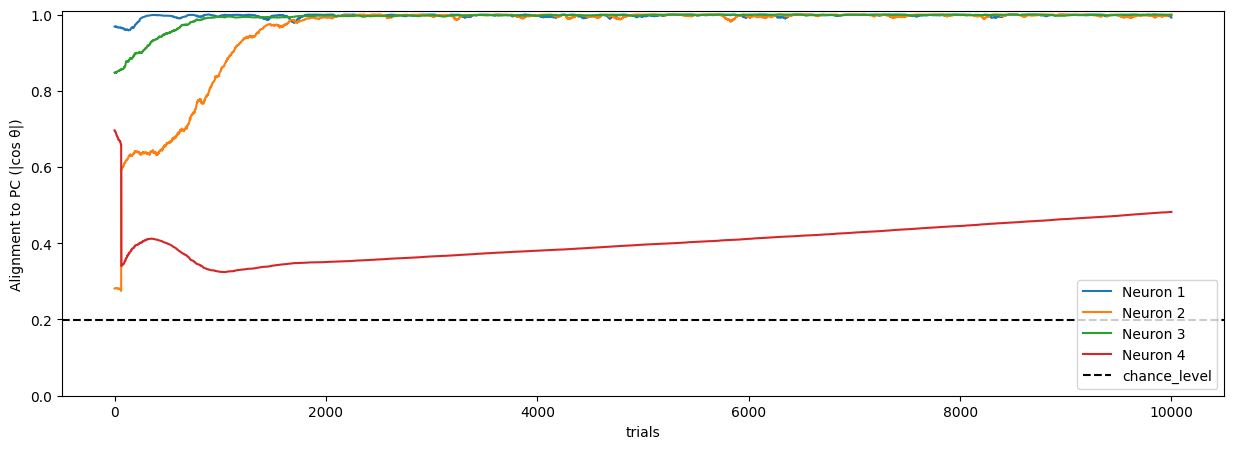

<Figure size 640x480 with 0 Axes>

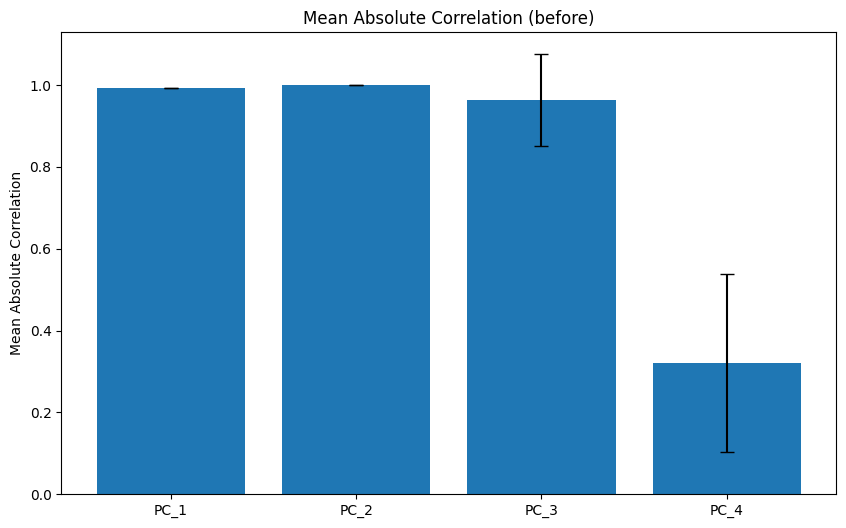

<Figure size 640x480 with 0 Axes>

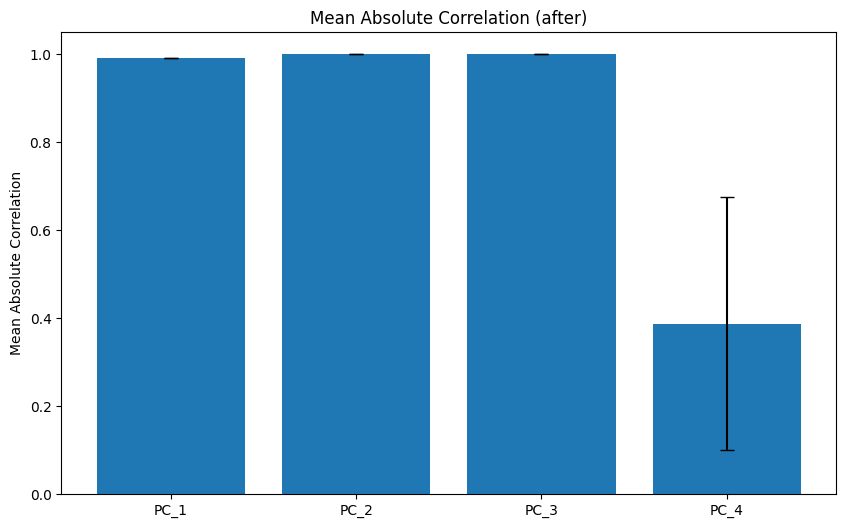

In [5]:
# leen_model  = OneShotLeenCompletePCA(**model_paras)
# leen_model = LeenCompletePCA(**model_paras)
# leen_model = LeenCompletePCA_TD(**_model_paras)
leen_model = OneShotLeenFreislebenPCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, 
                            # model_paras_after = model_paras_after, 
                            runs = 10, graph = True)

### Golden standard: Sanger's rule

run  1
X_before
step    0 | order = [1 2 0 3] | best|corr|= [0.258 0.192 0.117 0.241]
step 1000 | order = [0 1 3 2] | best|corr|= [0.987 0.994 0.001 0.996]
step 2000 | order = [0 1 3 2] | best|corr|= [0.951 0.979 0.039 0.999]
step 3000 | order = [0 1 3 2] | best|corr|= [0.923 0.985 0.018 0.984]
step 4000 | order = [0 1 2 3] | best|corr|= [0.964 0.999 0.995 0.037]
step 5000 | order = [0 1 2 3] | best|corr|= [0.997 0.983 0.996 0.209]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.973 0.992 0.432]
step 7000 | order = [0 1 2 3] | best|corr|= [0.977 0.996 0.997 0.779]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.983 0.999 0.943]
step 9000 | order = [0 1 2 3] | best|corr|= [0.979 0.994 0.997 0.985]
step 10000 | order = [0 1 2 3] | best|corr|= [0.82  0.983 0.997 0.996]


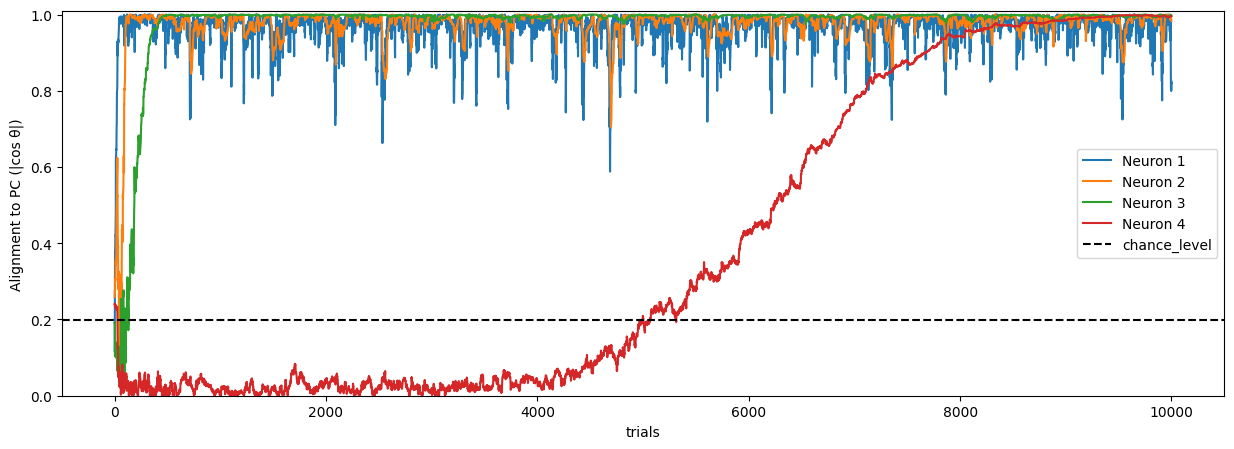

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.68  0.854 0.684 0.731]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.892]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.977]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.989]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.996]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


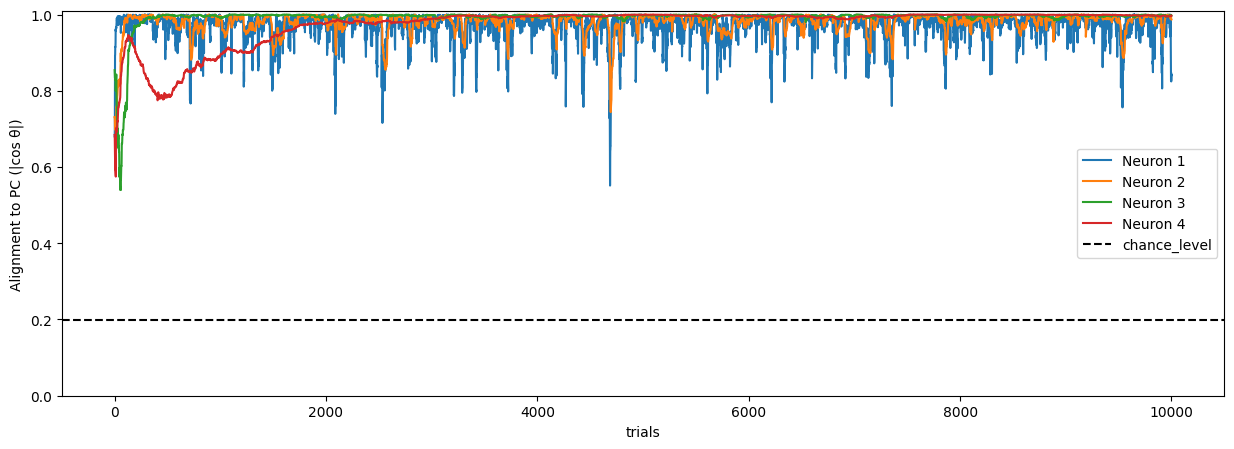

run  2
X_before
step    0 | order = [2 0 1 3] | best|corr|= [0.423 0.302 0.452 0.221]
step 1000 | order = [0 1 3 2] | best|corr|= [0.99  0.993 0.001 0.997]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.046]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.017]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.001]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.049]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.078]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.087]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.148]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.394]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.82 ]


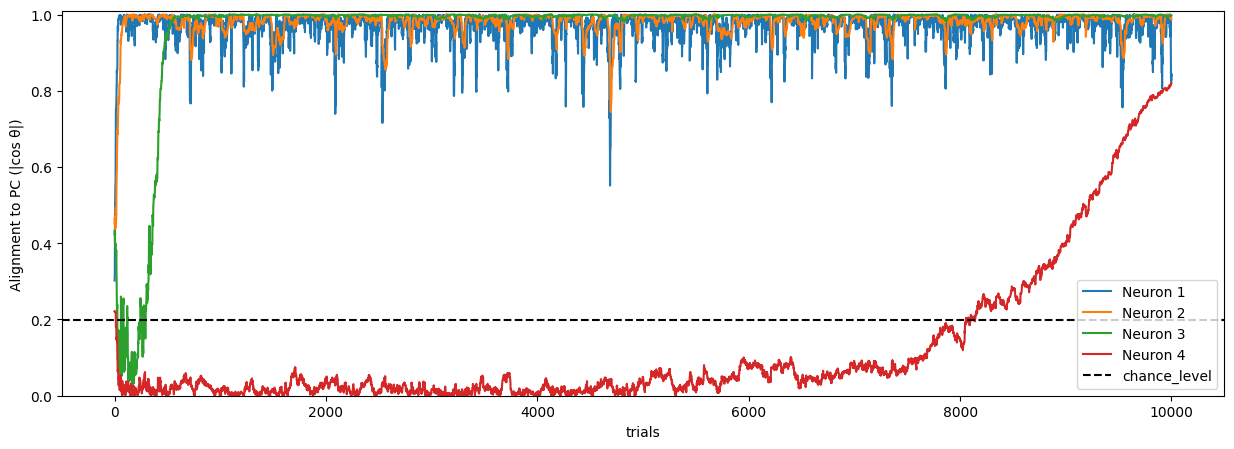

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.881]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.972]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.993]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.994]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.998]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


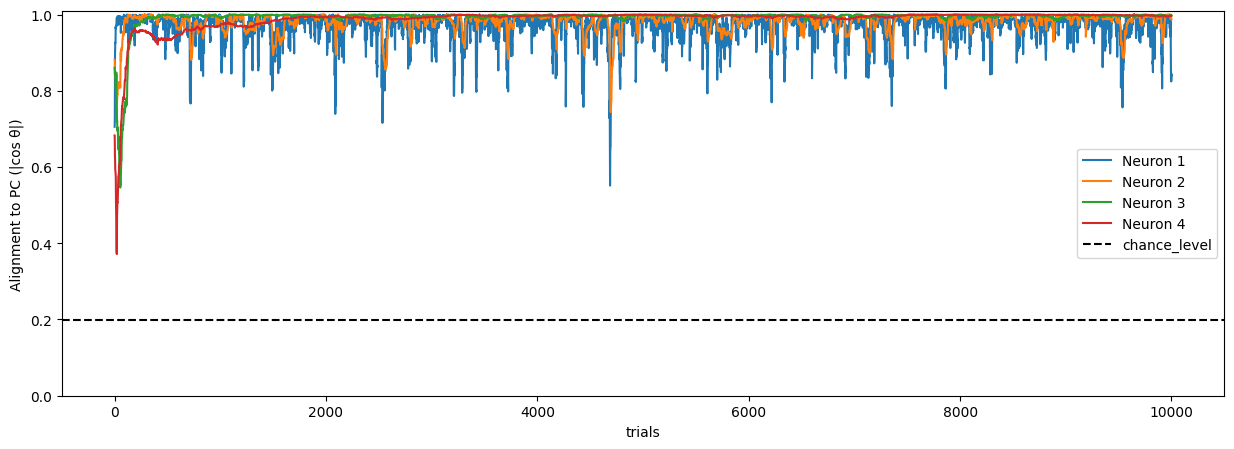

run  3
X_before
step    0 | order = [0 3 2 1] | best|corr|= [0.37  0.634 0.085 0.35 ]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.991 0.03 ]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.127]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.188]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.426]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.782]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.962]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.978]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.998]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


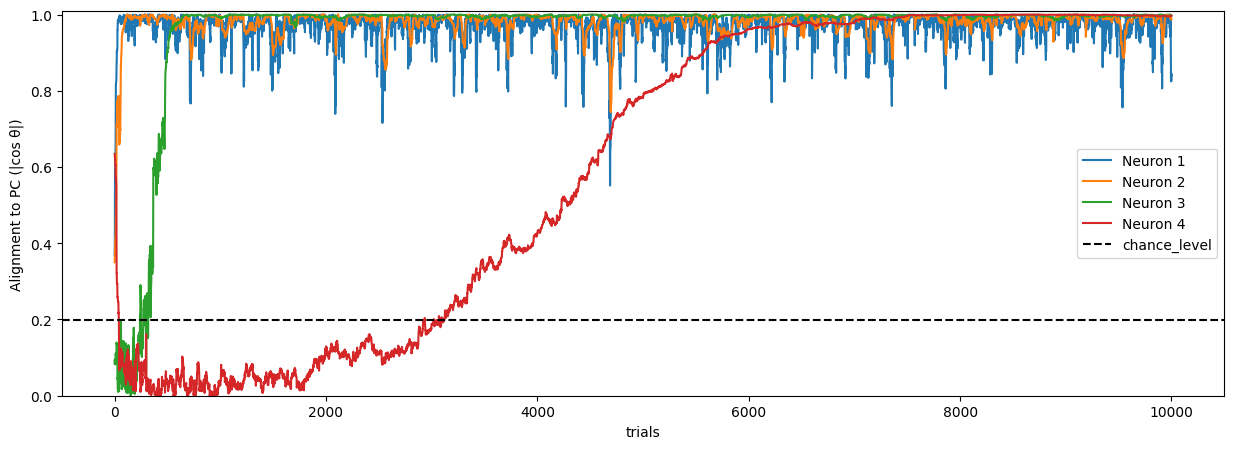

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.706]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.905]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.98 ]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.99 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


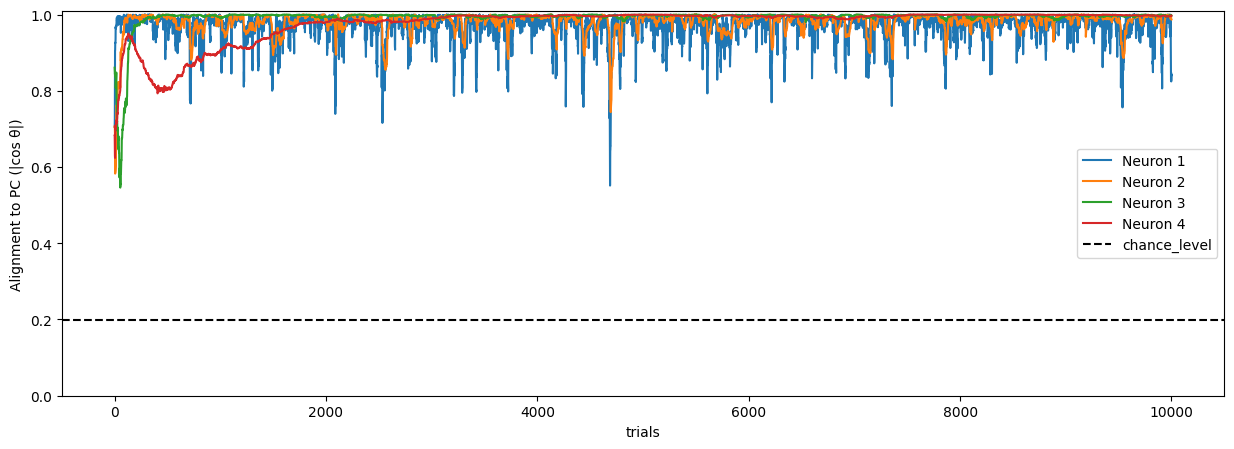

run  4
X_before
step    0 | order = [3 2 0 1] | best|corr|= [0.382 0.593 0.571 0.314]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.991 0.022]
step 2000 | order = [0 1 3 2] | best|corr|= [0.958 0.982 0.037 0.991]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.137]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.351]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.777]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.945]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.992]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.998]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


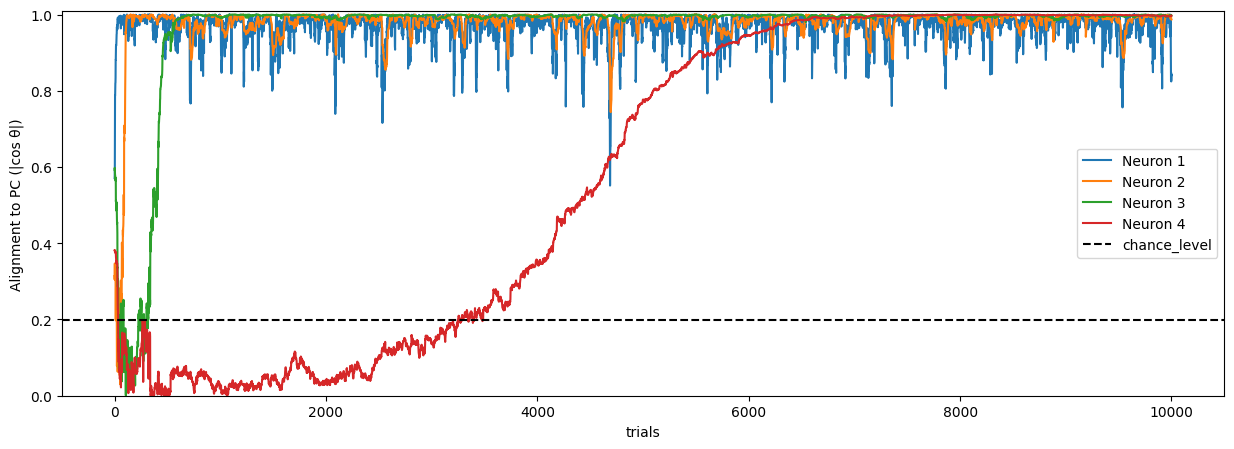

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.712]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.906]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.98 ]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.99 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


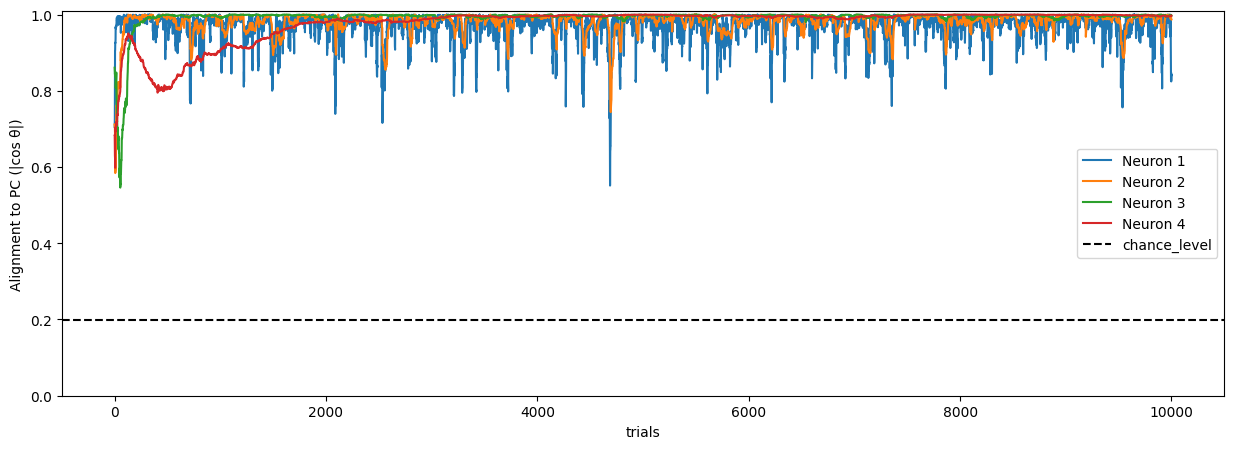

run  5
X_before
step    0 | order = [1 2 3 0] | best|corr|= [0.326 0.227 0.38  0.34 ]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.018]
step 2000 | order = [0 1 3 2] | best|corr|= [0.958 0.982 0.037 0.989]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.111]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.283]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.734]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.926]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.99 ]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.998]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.998]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


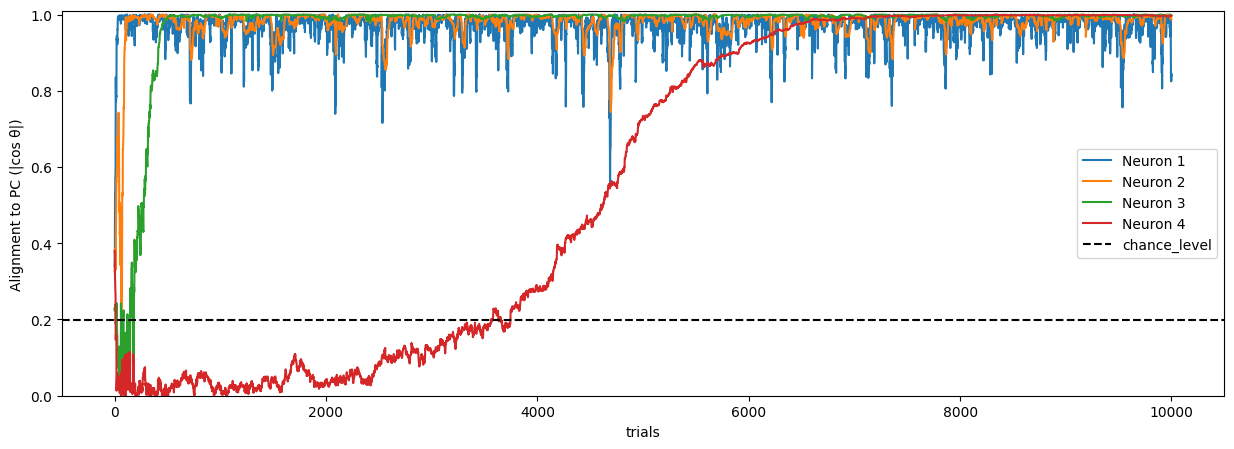

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.713]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.906]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.98 ]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.99 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


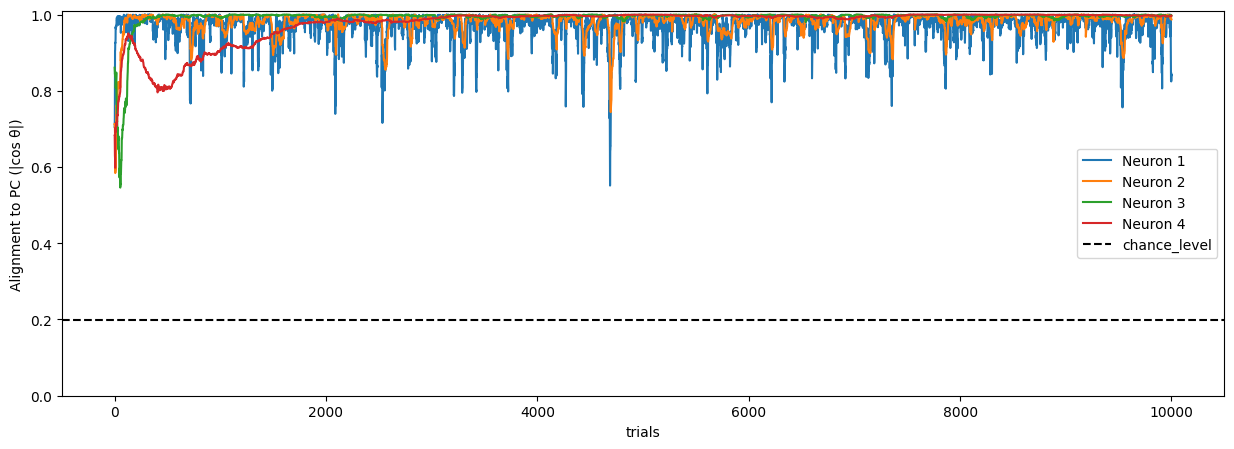

run  6
X_before
step    0 | order = [3 0 1 2] | best|corr|= [0.492 0.431 0.287 0.586]
step 1000 | order = [0 1 3 2] | best|corr|= [0.99  0.993 0.001 0.997]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.044]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.013]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.008]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.082]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.15 ]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.252]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.477]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.814]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.977]


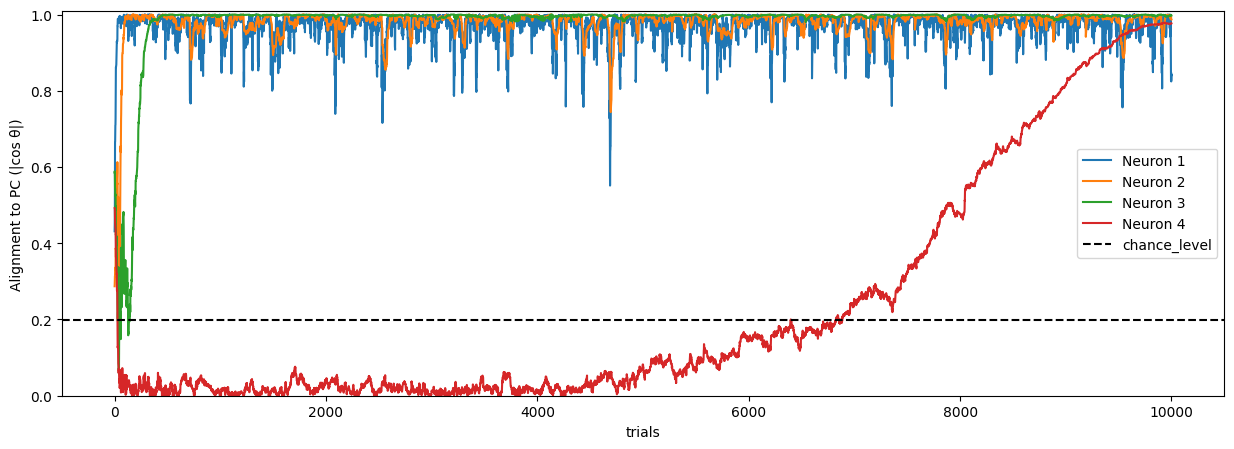

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.803]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.928]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.985]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.991]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


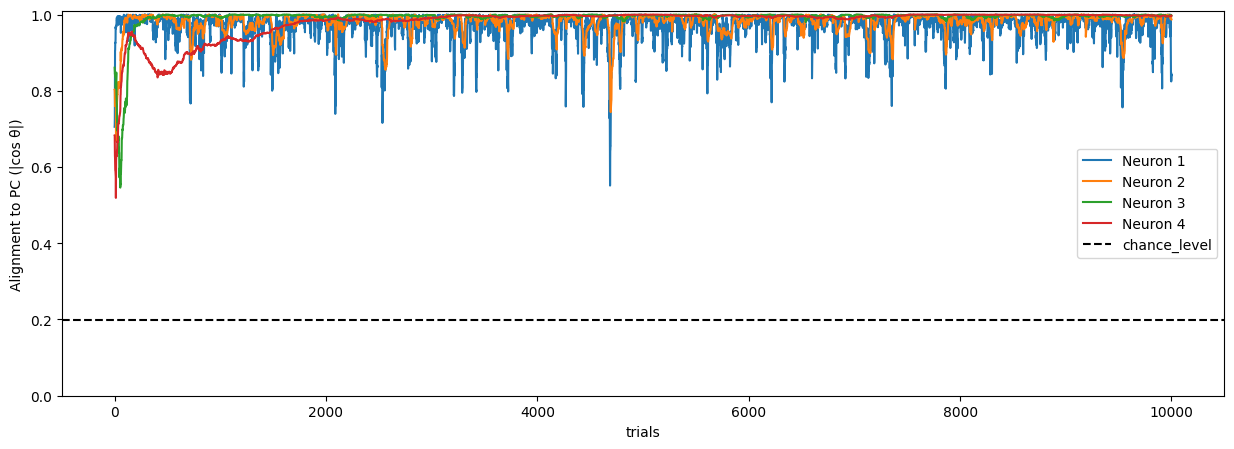

run  7
X_before
step    0 | order = [2 0 1 3] | best|corr|= [0.365 0.304 0.274 0.225]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.992 0.002]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.026]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.029]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.052]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.017]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.221]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.756]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.986]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.993]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.998]


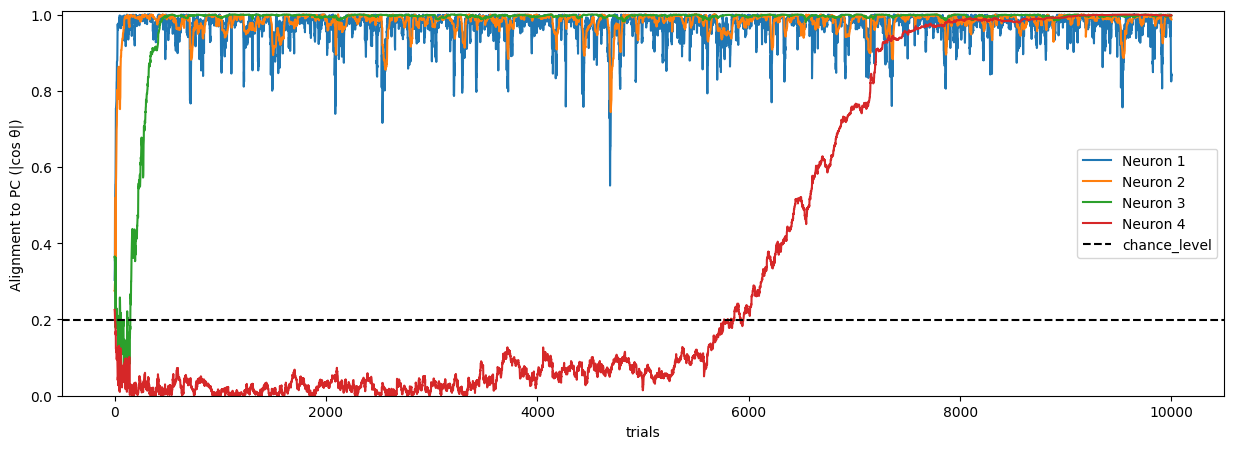

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.707]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.913]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.982]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.99 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


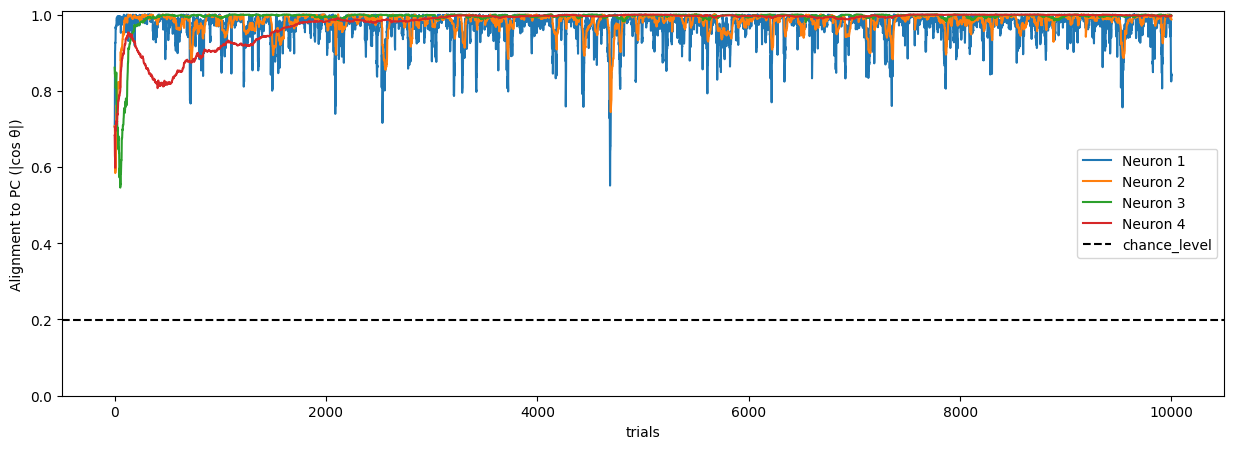

run  8
X_before
step    0 | order = [0 1 3 2] | best|corr|= [0.32  0.341 0.102 0.335]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.991 0.001]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.046]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.039]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.054]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.122]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.331]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.645]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.911]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.992]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.995]


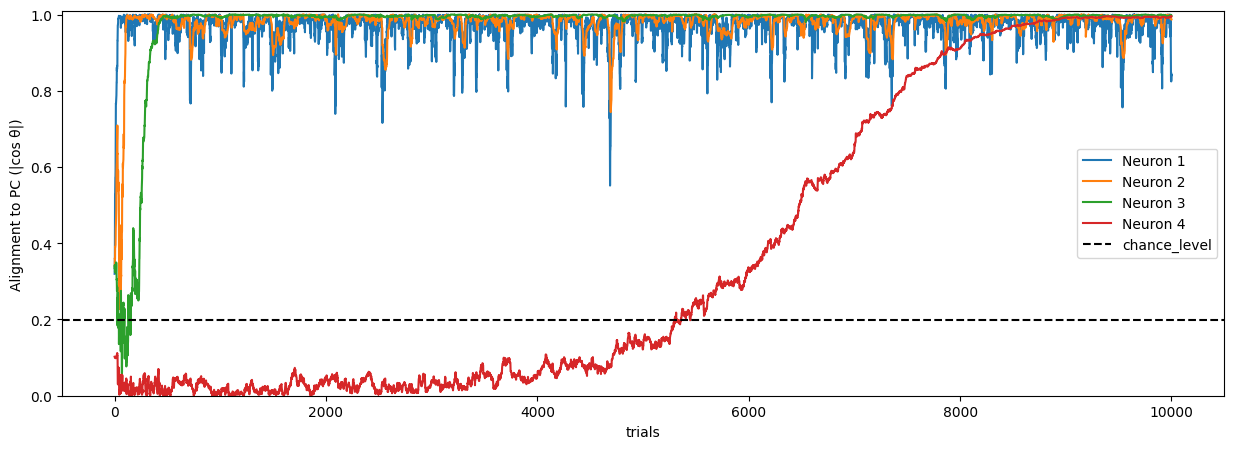

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.679]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.899]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.979]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.989]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


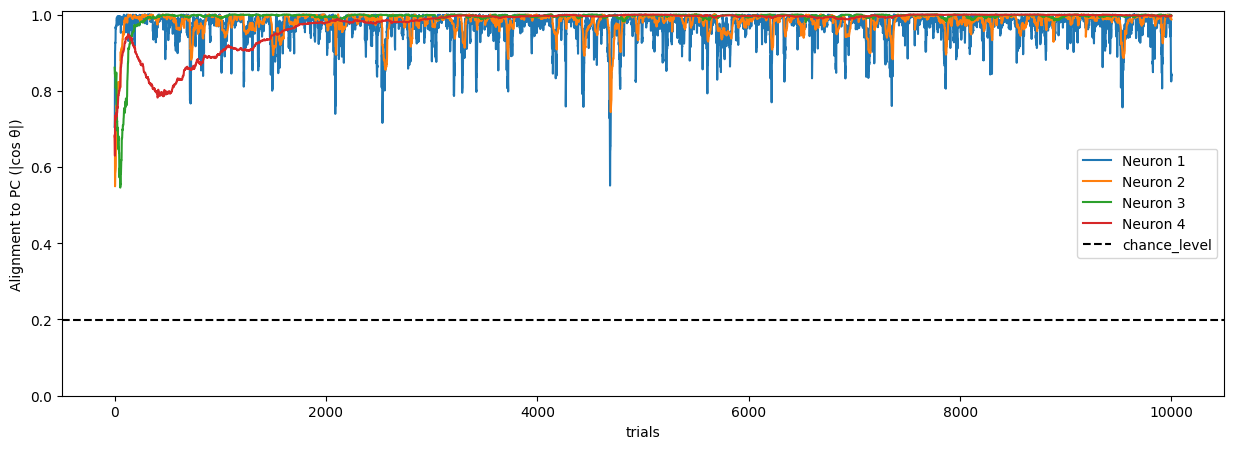

run  9
X_before
step    0 | order = [0 3 2 1] | best|corr|= [0.392 0.599 0.082 0.177]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.991 0.004]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.045]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.056]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.115]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.208]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.575]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.87 ]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.986]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 1.   ]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


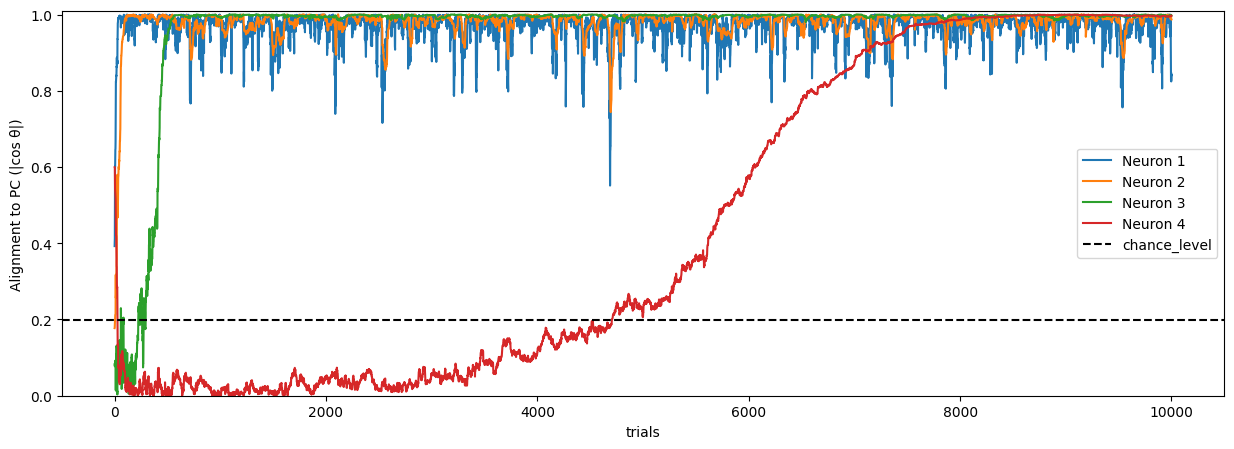

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.698]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.904]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.98 ]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.99 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


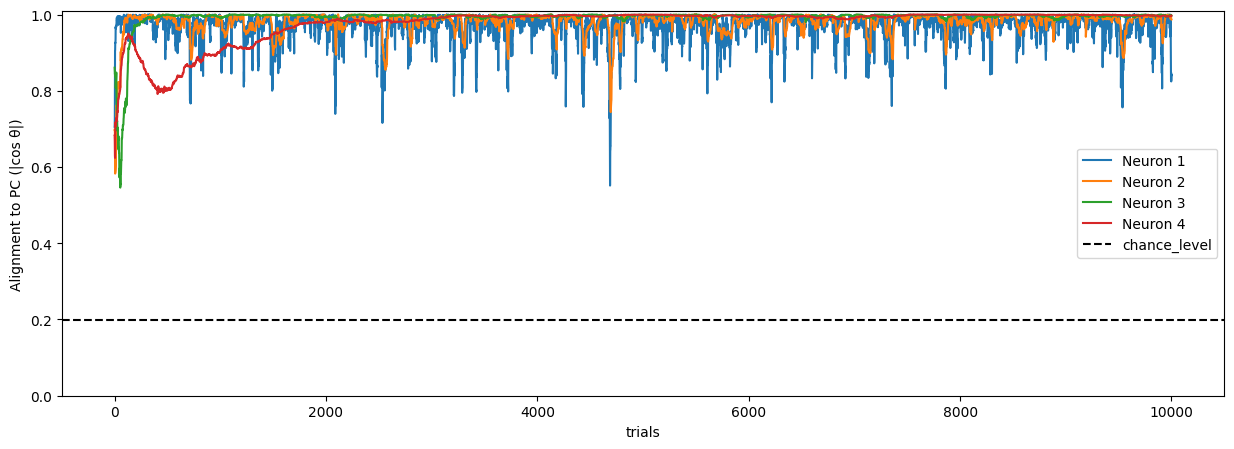

run 10
X_before
step    0 | order = [3 2 0 1] | best|corr|= [0.25  0.394 0.429 0.186]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.991 0.013]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.059]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.205]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.684]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.69 ]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.971]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.987]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    1.   ]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


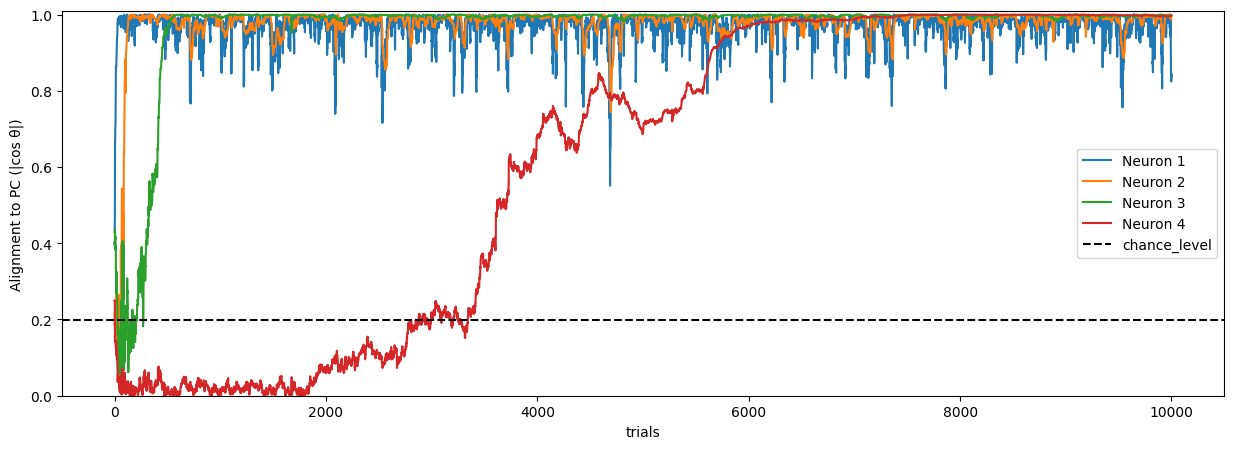

X_after
step    0 | order = [0 2 3 1] | best|corr|= [0.706 0.86  0.683 0.708]
step 1000 | order = [0 1 2 3] | best|corr|= [0.99  0.993 0.99  0.906]
step 2000 | order = [0 1 2 3] | best|corr|= [0.958 0.982 0.994 0.98 ]
step 3000 | order = [0 1 2 3] | best|corr|= [0.932 0.987 0.999 0.99 ]
step 4000 | order = [0 1 2 3] | best|corr|= [0.97  0.999 0.995 0.997]
step 5000 | order = [0 1 2 3] | best|corr|= [0.999 0.985 0.997 0.999]
step 6000 | order = [0 1 2 3] | best|corr|= [0.999 0.975 0.993 0.996]
step 7000 | order = [0 1 2 3] | best|corr|= [0.98  0.996 0.997 0.989]
step 8000 | order = [0 1 2 3] | best|corr|= [0.993 0.985 1.    0.999]
step 9000 | order = [0 1 2 3] | best|corr|= [0.984 0.995 0.997 0.999]
step 10000 | order = [0 1 2 3] | best|corr|= [0.841 0.987 0.997 0.997]


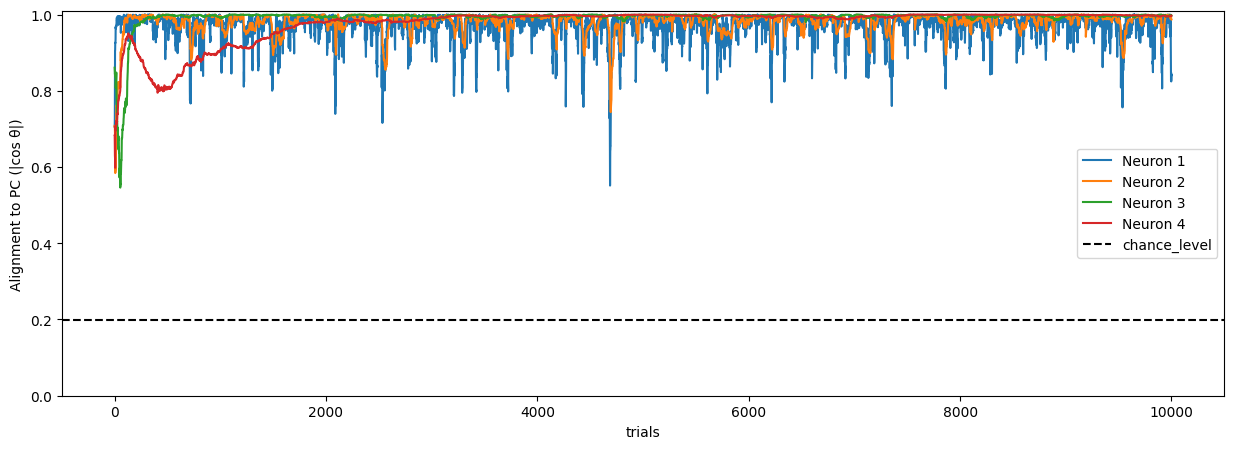

<Figure size 640x480 with 0 Axes>

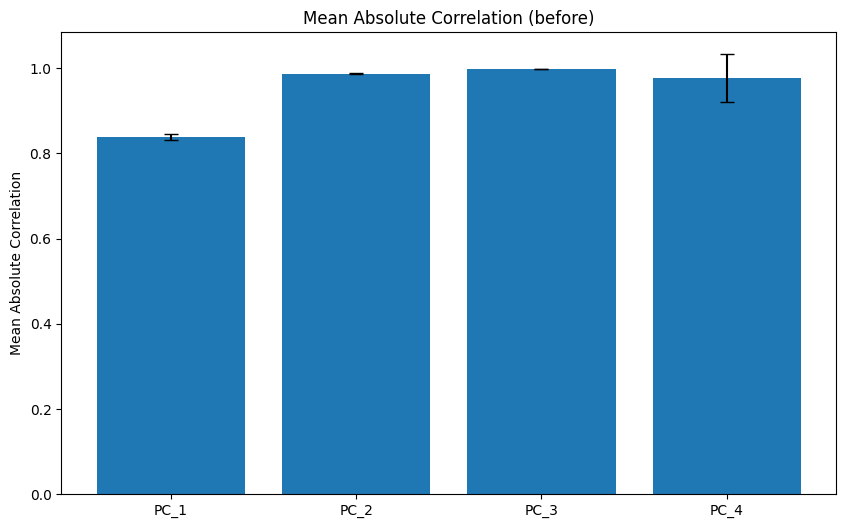

<Figure size 640x480 with 0 Axes>

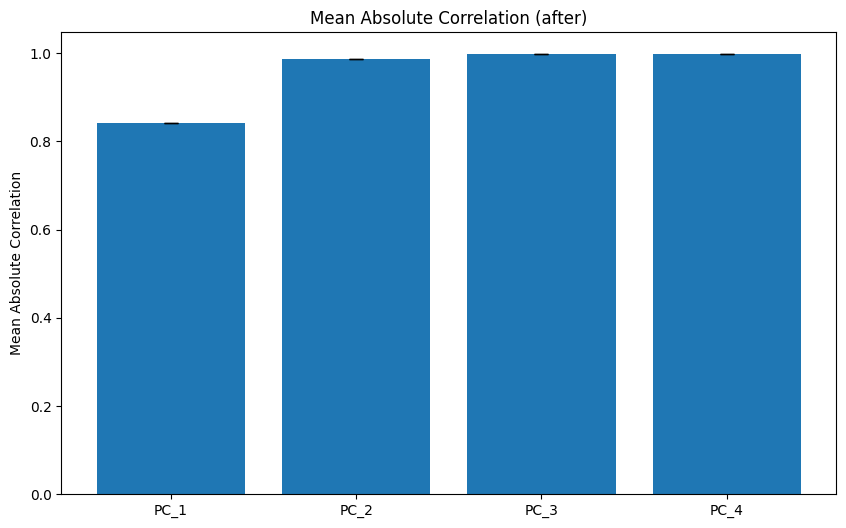

In [6]:
sanger_model = SangerNetwork(output_size=m, learning_rate=0.011, rng=None)

sanger_model_after = dict(learning_rate=0.01)

two_phase_training_testing(sanger_model, data_before=X_before, data_after=X_after, m=m, model_paras_after = sanger_model_after, runs = 10, graph = True)

### decoding task variable

In [5]:
from hebbian.utils import pca_topk, best_match_align_eigenvectors, sign_check
### calculate the task variable across time

# generate values between 0 and 1 for m number
rng_para = np.random.default_rng(seed=42)
params = rng_para.random(m)
batch_size = 1
# model = SangerNetwork(input_size=N, output_size=m, learning_rate=0.01)
# model = OneShotLeenCompletePCA(**model_paras)
# model = LeenCompletePCA(**_model_paras)
# model = OneShotLeenReislebenPCA(**model_paras)
model = OjaNetwork(input_size=N, output_size=m, learning_rate=0.01)

# get the weighted sum of the PC scores across all samples, using X_before
pcs, _, scores = pca_topk(X_before, k=m)
# calculate the task variable across time
task_var = np.dot(scores, params)


for step in range(0, n_samples, batch_size):
    X_train = X_before[step:step+batch_size]
    model.step(X_train)
    # use the X_mask to incrementally reveal the input matrix, and update the model

Y_output = model.transform(X_before)
# get the best match alignment between Y_output and PC_scores by hungarian algorithm
try:
    V = model.V
except:
    V = None

order, sim, _ = best_match_align_eigenvectors(model.W, V=V, eigenvectors=pcs)
print(order, sim)

signs = sign_check(Y_output, scores, order)

# Apply sign corrections
Y_output_signed = Y_output * signs[None, :]

# Now compute task variable with sign-corrected output
task_var_tilde = np.dot(Y_output_signed, params)

[3 2 1 0] [0.76323713 0.63270606 0.7717782  0.5356729 ]


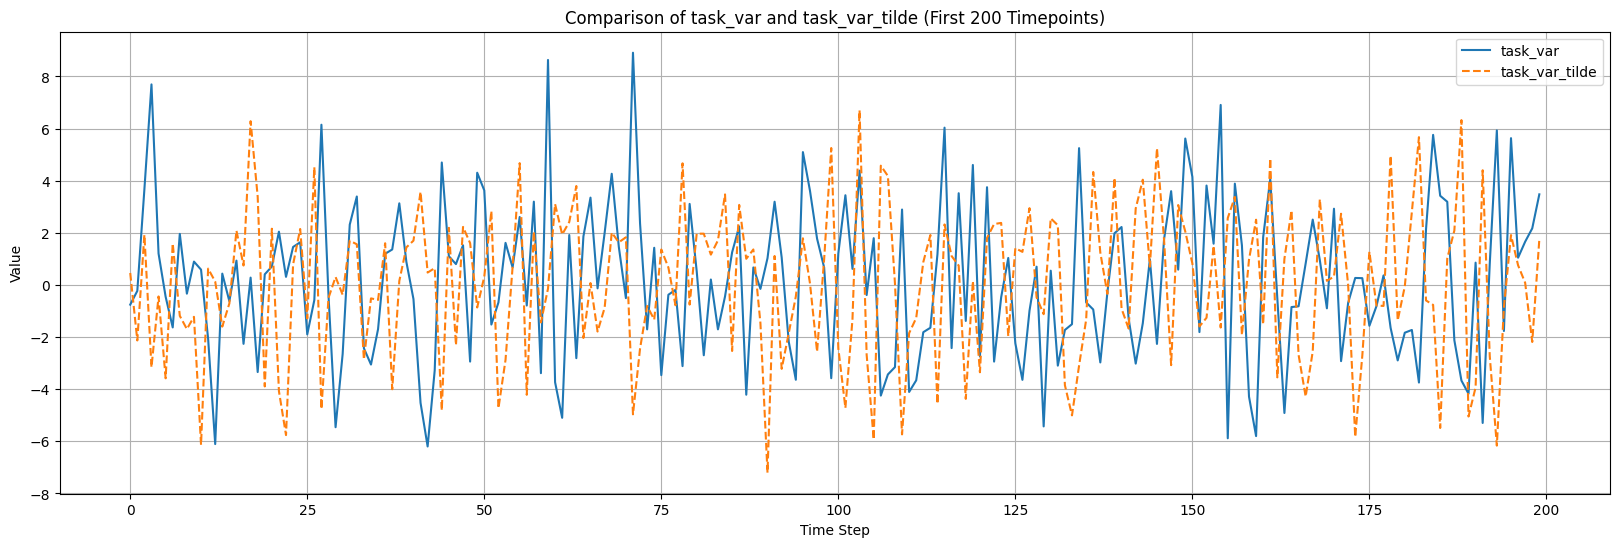

r^2 between task_var and task_var_tilde: -1.470344820511571


In [7]:
from sklearn.metrics import r2_score
# visualize
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_tilde[:200], label='task_var_tilde', linestyle='--')
plt.xlabel('Time Step') # Assuming an underlying time or step index
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_tilde (First 200 Timepoints)')
plt.legend()
plt.grid(True)
plt.show()

# get r^2 between task_var and task_var_tilde
r2 = r2_score(task_var, task_var_tilde)
print(f"r^2 between task_var and task_var_tilde: {r2}")


### With random initialization in model weights, as baseline

[0 3 1 2] [0.45390279 0.12280213 0.34447091 0.23522595]


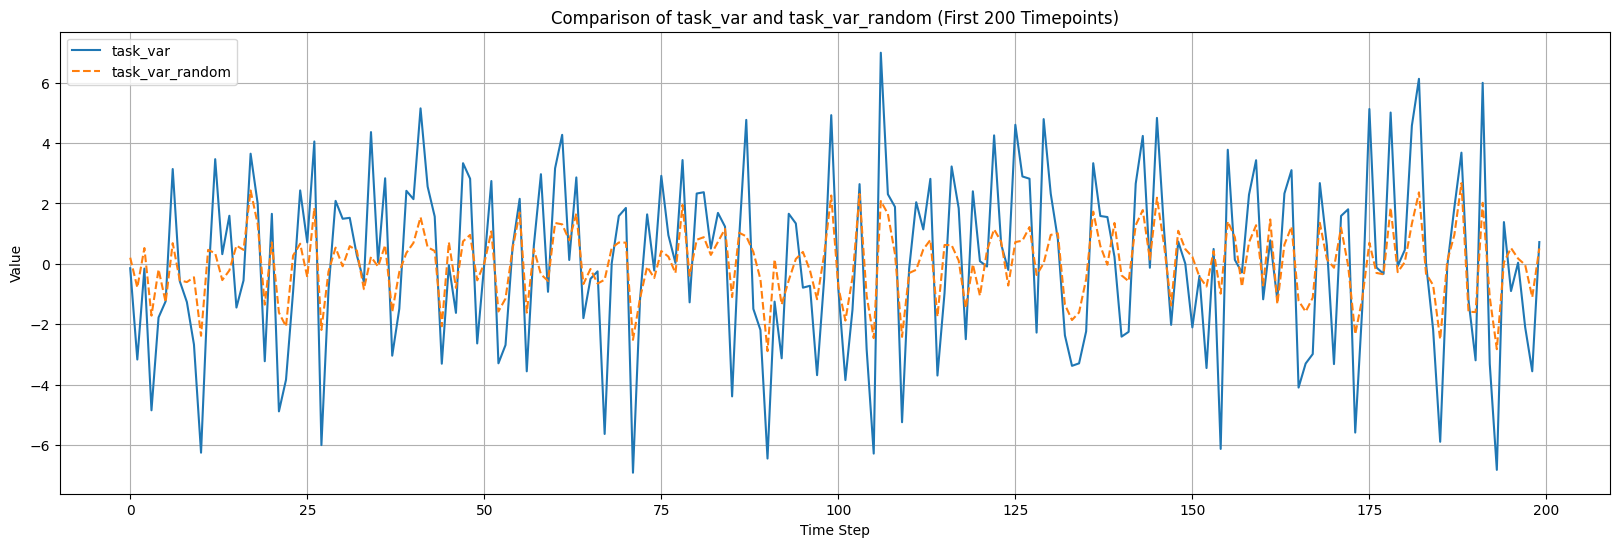

r^2 between task_var and task_var_random: 0.5333081849867995


In [ ]:
# model = SangerNetwork(input_size=N, output_size=m, learning_rate=0.01)
# model = OneShotLeenCompletePCA(**model_paras)
# model = LeenCompletePCA(**_model_paras)
# model = OneShotLeenReislebenPCA(**model_paras)
model = OjaNetwork(**model_paras)
Y_output_random = model.transform(X_before)

order, sim, _ = best_match_align_eigenvectors(model.W, V=V, eigenvectors=pcs)
print(order, sim)

signs = sign_check(Y_output_random, scores, order)
# Apply sign corrections
Y_output_signed_random = Y_output_random * signs[None, :]
# Now compute task variable with sign-corrected output
task_var_random = np.dot(Y_output_signed_random, params)

# visualize
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_random[:200], label='task_var_random', linestyle='--')
plt.xlabel('Time Step') # Assuming an underlying time or step index
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_random (First 200 Timepoints)')
plt.legend()
plt.grid(True)
plt.show()

# get r^2 between task_var and task_var_random
r2 = r2_score(task_var, task_var_random)
print(f"r^2 between task_var and task_var_random: {r2}")

### Chance level exploration with random vectors

In [10]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [11]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

Analytical chance correlation: 0.199


In [12]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

NameError: name 'rotate_cov_nd' is not defined

In [ ]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")